# Importation des bibliothèques et exploration initiale du jeu de données

In [2]:
# Import des bibliothèques
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from scipy.stats import shapiro
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Options d'affichage
pd.set_option('display.max_columns', None)
sns.set(style="whitegrid", palette="muted")

# Chargement du dataset
df = pd.read_csv("StudentPerformanceFactors.csv")

# Aperçu général
print(f"Dimensions du dataset : {df.shape}")
display(df.head())
display(df.info())

# Résumé rapide des variables
print("\nAperçu statistique des variables :")
display(df.describe(include='all').T.head(10))

Dimensions du dataset : (6607, 20)


,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
0,23,84,Low,High,No,7,73,Low,Yes,0,Low,Medium,Public,Positive,3,No,High School,Near,Male,67
1,19,64,Low,Medium,No,8,59,Low,Yes,2,Medium,Medium,Public,Negative,4,No,College,Moderate,Female,61
2,24,98,Medium,Medium,Yes,7,91,Medium,Yes,2,Medium,Medium,Public,Neutral,4,No,Postgraduate,Near,Male,74
3,29,89,Low,Medium,Yes,8,98,Medium,Yes,1,Medium,Medium,Public,Negative,4,No,High School,Moderate,Male,71
4,19,92,Medium,Medium,Yes,6,65,Medium,Yes,3,Medium,High,Public,Neutral,4,No,College,Near,Female,70


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6607 entries, 0 to 6606
Data columns (total 20 columns):
 #   Column                      Non-Null Count  Dtype 
---  ------                      --------------  ----- 
 0   Hours_Studied               6607 non-null   int64 
 1   Attendance                  6607 non-null   int64 
 2   Parental_Involvement        6607 non-null   object
 3   Access_to_Resources         6607 non-null   object
 4   Extracurricular_Activities  6607 non-null   object
 5   Sleep_Hours                 6607 non-null   int64 
 6   Previous_Scores             6607 non-null   int64 
 7   Motivation_Level            6607 non-null   object
 8   Internet_Access             6607 non-null   object
 9   Tutoring_Sessions           6607 non-null   int64 
 10  Family_Income               6607 non-null   object
 11  Teacher_Quality             6529 non-null   object
 12  School_Type                 6607 non-null   object
 13  Peer_Influence              6607 non-null   obje

None


Aperçu statistique des variables :


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Hours_Studied,6607.0,NaN,NaN,NaN,19.975329,5.990594,1.0,16.0,20.0,24.0,44.0
Attendance,6607.0,NaN,NaN,NaN,79.977448,11.547475,60.0,70.0,80.0,90.0,100.0
Parental_Involvement,6607,3,Medium,3362,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Access_to_Resources,6607,3,Medium,3319,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Extracurricular_Activities,6607,2,Yes,3938,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Sleep_Hours,6607.0,NaN,NaN,NaN,7.02906,1.46812,4.0,6.0,7.0,8.0,10.0
Previous_Scores,6607.0,NaN,NaN,NaN,75.070531,14.399784,50.0,63.0,75.0,88.0,100.0
Motivation_Level,6607,3,Medium,3351,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Internet_Access,6607,2,Yes,6108,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Tutoring_Sessions,6607.0,NaN,NaN,NaN,1.493719,1.23057,0.0,1.0,1.0,2.0,8.0


Interprétation :
Le dataset contient 6 607 étudiants décrits par 19 variables explicatives et une variable cible Exam_Score.
Les variables quantitatives concernent principalement les habitudes d’étude (Hours_Studied, Attendance, Sleep_Hours, etc.), tandis que les variables qualitatives décrivent le contexte social et éducatif (Parental_Involvement, Motivation_Level, etc.).

Trois variables présentent des valeurs manquantes modérées : Teacher_Quality, Parental_Education_Level et Distance_from_Home.
Ces variables seront nettoyées ou imputées avant la phase de modélisation.

La diversité des variables (comportementales, familiales, scolaires) rend ce jeu de données particulièrement adapté à l’analyse multivariée et à la construction de modèles prédictifs de performance académique.

# Analyse de la structure, des types de données et de la distribution des variables

In [3]:
# Statistiques descriptives des variables numériques
display(df.describe())

# Aperçu des valeurs uniques pour les variables qualitatives
for col in df.select_dtypes(include='object').columns:
    print(f"\n {col}")
    print(df[col].value_counts())

# Vérification des valeurs manquantes
print("\nValeurs manquantes par colonne :")
print(df.isna().sum())

,Hours_Studied,Attendance,Sleep_Hours,Previous_Scores,Tutoring_Sessions,Physical_Activity,Exam_Score
count,6607.000000,6607.000000,6607.00000,6607.000000,6607.000000,6607.000000,6607.000000
mean,19.975329,79.977448,7.02906,75.070531,1.493719,2.967610,67.235659
std,5.990594,11.547475,1.46812,14.399784,1.230570,1.031231,3.890456
min,1.000000,60.000000,4.00000,50.000000,0.000000,0.000000,55.000000
25%,16.000000,70.000000,6.00000,63.000000,1.000000,2.000000,65.000000
50%,20.000000,80.000000,7.00000,75.000000,1.000000,3.000000,67.000000
75%,24.000000,90.000000,8.00000,88.000000,2.000000,4.000000,69.000000
max,44.000000,100.000000,10.00000,100.000000,8.000000,6.000000,101.000000



 Parental_Involvement
Parental_Involvement
Medium    3362
High      1908
Low       1337
Name: count, dtype: int64

 Access_to_Resources
Access_to_Resources
Medium    3319
High      1975
Low       1313
Name: count, dtype: int64

 Extracurricular_Activities
Extracurricular_Activities
Yes    3938
No     2669
Name: count, dtype: int64

 Motivation_Level
Motivation_Level
Medium    3351
Low       1937
High      1319
Name: count, dtype: int64

 Internet_Access
Internet_Access
Yes    6108
No      499
Name: count, dtype: int64

 Family_Income
Family_Income
Low       2672
Medium    2666
High      1269
Name: count, dtype: int64

 Teacher_Quality
Teacher_Quality
Medium    3925
High      1947
Low        657
Name: count, dtype: int64

 School_Type
School_Type
Public     4598
Private    2009
Name: count, dtype: int64

 Peer_Influence
Peer_Influence
Positive    2638
Neutral     2592
Negative    1377
Name: count, dtype: int64

 Learning_Disabilities
Learning_Disabilities
No     5912
Yes     695
Name: 

Le jeu de données contient 6 607 étudiants décrits par 19 variables explicatives et une variable cible Exam_Score.
Les statistiques descriptives montrent des valeurs cohérentes et réalistes pour l’ensemble des variables numériques.

Les variables catégorielles sont de deux types :
	•	Ordinales : présentant un ordre logique (Low/Medium/High, Near/Moderate/Far, etc.)
	•	Binaires : de type Yes/No ou Male/Female.

Trois variables présentent des valeurs manquantes faibles (<2%), ce qui sera corrigé par imputation du mode.

Ce dataset est globalement bien structuré et équilibré, prêt à être nettoyé et encodé pour la phase de modélisation.

# Gestion des valeurs manquantes par imputation des modes

In [4]:
# Imputation des valeurs manquantes (mode)
df["Teacher_Quality"] = df["Teacher_Quality"].fillna(df["Teacher_Quality"].mode()[0])
df["Parental_Education_Level"] = df["Parental_Education_Level"].fillna(df["Parental_Education_Level"].mode()[0])
df["Distance_from_Home"] = df["Distance_from_Home"].fillna(df["Distance_from_Home"].mode()[0])

# Vérification après imputation
print("\nValeurs manquantes après imputation :")
print(df.isna().sum())


Valeurs manquantes après imputation :
Hours_Studied                 0
Attendance                    0
Parental_Involvement          0
Access_to_Resources           0
Extracurricular_Activities    0
Sleep_Hours                   0
Previous_Scores               0
Motivation_Level              0
Internet_Access               0
Tutoring_Sessions             0
Family_Income                 0
Teacher_Quality               0
School_Type                   0
Peer_Influence                0
Physical_Activity             0
Learning_Disabilities         0
Parental_Education_Level      0
Distance_from_Home            0
Gender                        0
Exam_Score                    0
dtype: int64


Trois variables qualitatives présentaient des valeurs manquantes : Teacher_Quality, Parental_Education_Level, Distance_from_Home

Ces valeurs ont été remplacées par leur modalité la plus fréquente (mode).
Cette méthode d’imputation est adaptée aux variables catégorielles, car elle :
	préserve la taille du jeu de données (aucune suppression de lignes) ;
	conserve la distribution initiale des modalités ;
	limite le risque de distorsion statistique, les valeurs manquantes représentant moins de 2 % des observations.

Après cette étape, le dataset ne contient plus de valeurs manquantes et est prêt pour la phase d’encodage des variables.

#  Vérification de l’imputation

In [5]:
df[["Teacher_Quality", "Parental_Education_Level", "Distance_from_Home"]].isna().sum()
print("Vérification réussie : aucune valeur manquante détectée après imputation.")

Vérification réussie : aucune valeur manquante détectée après imputation.


## Toutes les valeurs manquantes ont été correctement imputées.
Les trois variables concernées (Teacher_Quality, Parental_Education_Level, Distance_from_Home) affichent désormais zéro valeur manquante, confirmant la qualité du nettoyage.

# Exploration des distributions des variables quantitatives

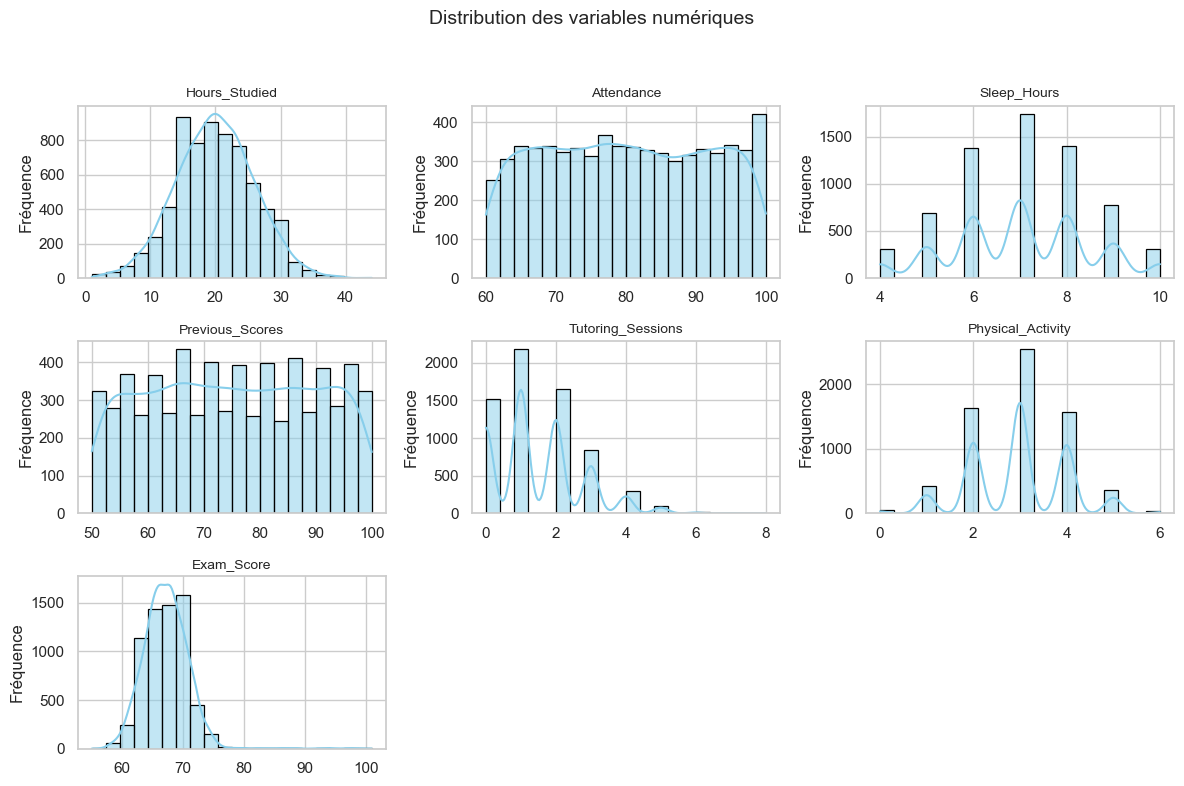


Valeurs de Exam_Score supérieures à 100 :
      Hours_Studied  Attendance Parental_Involvement Access_to_Resources  \
1525             27          98                  Low              Medium   

     Extracurricular_Activities  Sleep_Hours  Previous_Scores  \
1525                        Yes            6               93   

     Motivation_Level Internet_Access  Tutoring_Sessions Family_Income  \
1525              Low              No                  5          High   

     Teacher_Quality School_Type Peer_Influence  Physical_Activity  \
1525            High      Public       Positive                  3   

     Learning_Disabilities Parental_Education_Level Distance_from_Home  \
1525                    No              High School           Moderate   

      Gender  Exam_Score  
1525  Female         101  


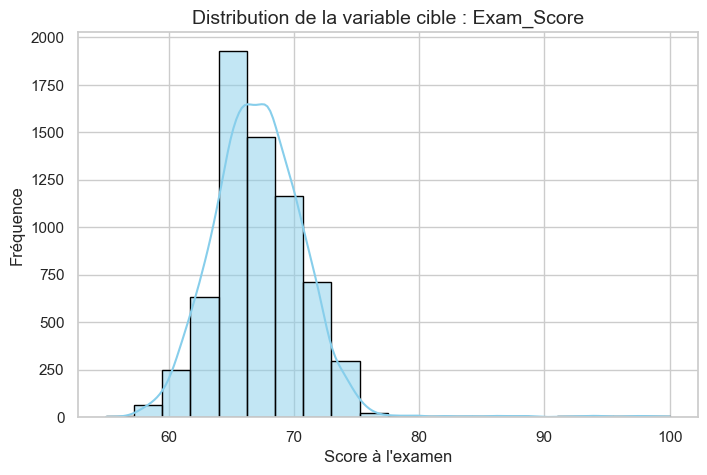

In [6]:
# Exploration des distributions des variables numériques
import seaborn as sns
import matplotlib.pyplot as plt

# Sélection des variables numériques
num_vars = df.select_dtypes(include=np.number).columns

# Visualisation individuelle des distributions
plt.figure(figsize=(12, 8))
for i, col in enumerate(num_vars, 1):
    plt.subplot(3, 3, i)
    sns.histplot(df[col], bins=20, kde=True, color="skyblue", edgecolor="black")
    plt.title(col, fontsize=10)
    plt.xlabel("")
    plt.ylabel("Fréquence")

plt.suptitle("Distribution des variables numériques", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

# Vérification et correction d'éventuelles valeurs aberrantes sur la variable cible
outliers = df[df["Exam_Score"] > 100]
print("\nValeurs de Exam_Score supérieures à 100 :")
print(outliers)

# Correction si nécessaire
df.loc[df["Exam_Score"] > 100, "Exam_Score"] = 100

# Zoom sur la variable cible : Exam_Score
plt.figure(figsize=(8,5))
sns.histplot(df["Exam_Score"], bins=20, kde=True, color="skyblue", edgecolor="black")
plt.title("Distribution de la variable cible : Exam_Score", fontsize=14)
plt.xlabel("Score à l'examen")
plt.ylabel("Fréquence")
plt.show()

## Les distributions montrent des profils variés selon les indicateurs :

Ces visualisations mettent en évidence la répartition des principales variables numériques du jeu de données :

- Les variables Hours_Studied et Sleep_Hours suivent approximativement une distribution normale, traduisant une répartition équilibrée des comportements étudiants.
- La variable Tutoring_Sessions présente une asymétrie marquée, indiquant que la majorité des étudiants bénéficient de peu de séances de soutien, tandis qu’une minorité en suit davantage.
- La variable cible Exam_Score affiche une distribution en cloche centrée autour de 67, suggérant une performance moyenne globalement satisfaisante et une dispersion modérée.

Une vérification des valeurs extrêmes a permis de détecter une seule observation avec un Exam_Score supérieur à 100.
Cette valeur aberrante a été corrigée à 100 afin de préserver la cohérence statistique du jeu de données sans supprimer l’observation correspondante.

Dans l’ensemble, les distributions sont cohérentes et réalistes, confirmant la bonne qualité du jeu de données et sa préparation adéquate pour les analyses corrélationnelles et la modélisation prédictive.

# Corrélation entre les variables quantitatives et la performance académique (Exam_Score)

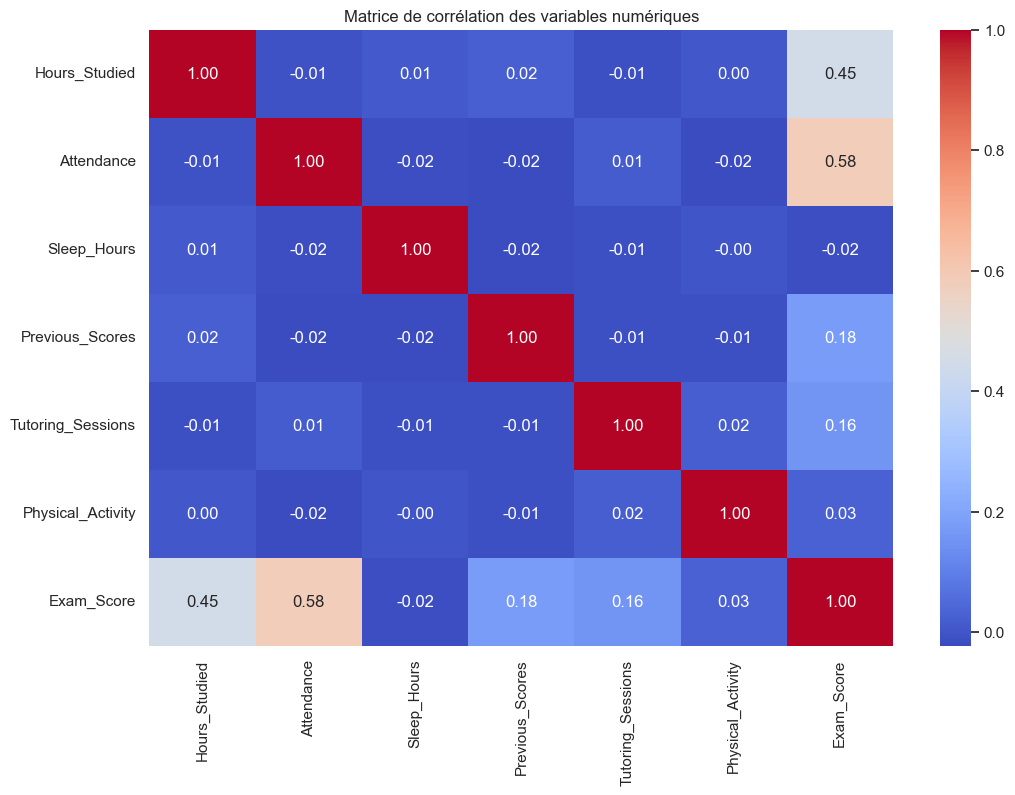

Exam_Score           1.000000
Attendance           0.581205
Hours_Studied        0.445558
Previous_Scores      0.175089
Tutoring_Sessions    0.156466
Physical_Activity    0.027832
Sleep_Hours         -0.017000
Name: Exam_Score, dtype: float64

In [7]:
corr = df[num_vars].corr()

plt.figure(figsize=(12, 8))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Matrice de corrélation des variables numériques")
plt.show()

corr_target = corr["Exam_Score"].sort_values(ascending=False)
display(corr_target)

## L’analyse de corrélation met en évidence plusieurs relations intéressantes :

- Les variables Attendance et Hours_Studied ressortent comme les deux prédicteurs majeurs du score final.
- Les corrélations faibles entre les autres variables montrent une indépendance suffisante entre les facteurs explicatifs.
- L’absence de corrélation forte entre les variables numériques (hors cible) confirme qu’il n’y a pas de multicolinéarité sévère, ce qui facilitera l’interprétation des coefficients dans les modèles de régression.

La matrice de corrélation met en évidence la relation linéaire entre les variables quantitatives du jeu de données.

Les résultats montrent que :

- La présence en cours (Attendance) et le nombre d’heures d’étude (Hours_Studied) sont les variables les plus corrélées positivement au score final (Exam_Score).
- Les performances passées (Previous_Scores) et le nombre de séances de tutorat (Tutoring_Sessions) présentent un effet positif plus modéré.
- Aucune corrélation négative marquée n’est observée.

Ces observations suggèrent que l’assiduité et l’effort personnel sont les principaux leviers de la réussite scolaire dans cet échantillon.
De plus, les faibles corrélations entre les variables explicatives indiquent une absence de colinéarité majeure, permettant de poursuivre vers une modélisation fiable.

# Relations entre les variables académiques et le score d’examen

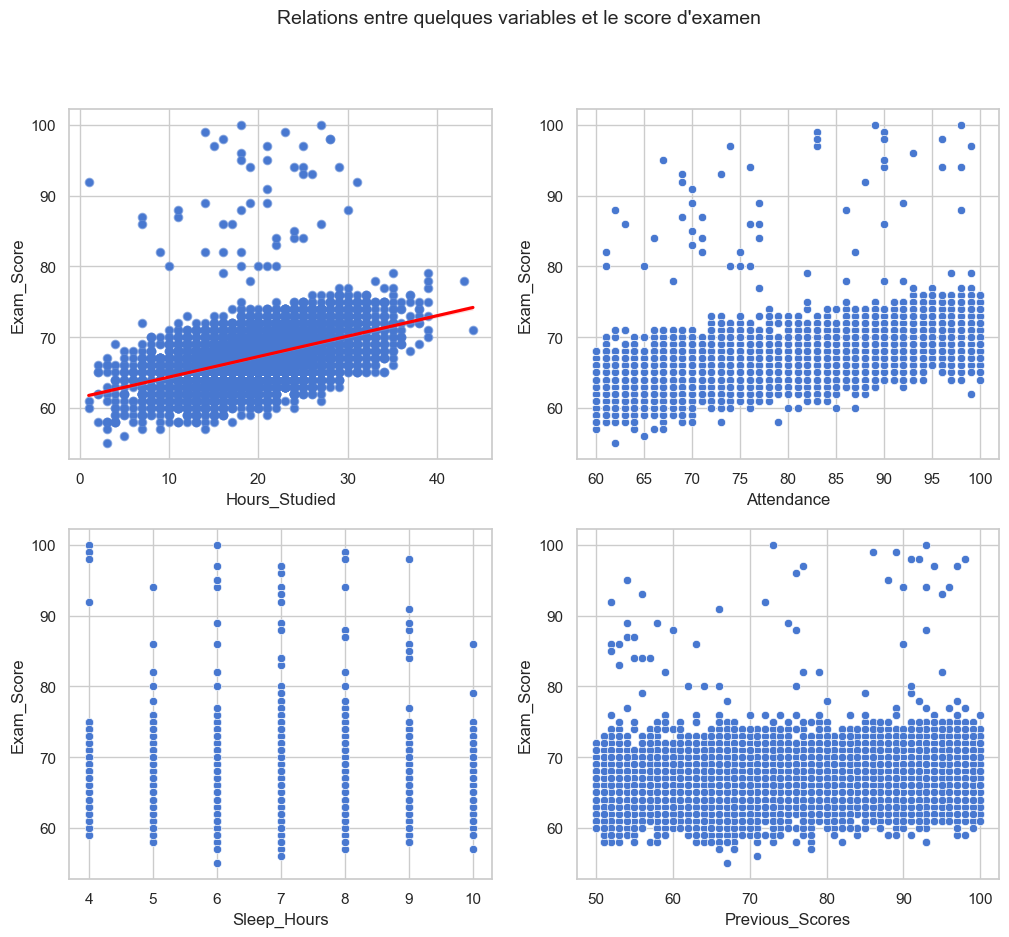

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

sns.scatterplot(ax=axes[0,0], data=df, x="Hours_Studied", y="Exam_Score")
sns.scatterplot(ax=axes[0,1], data=df, x="Attendance", y="Exam_Score")
sns.scatterplot(ax=axes[1,0], data=df, x="Sleep_Hours", y="Exam_Score")
sns.scatterplot(ax=axes[1,1], data=df, x="Previous_Scores", y="Exam_Score")
sns.regplot(ax=axes[0,0], data=df, x="Hours_Studied", y="Exam_Score", scatter_kws={'alpha':0.5}, line_kws={'color':'red'})

fig.suptitle("Relations entre quelques variables et le score d'examen", fontsize=14)
plt.show()

## Les graphiques mettent clairement en évidence les tendances suivantes :

Ces nuages de points permettent de visualiser les relations entre plusieurs variables explicatives et le score final (Exam_Score).

Les tendances confirment les résultats issus de la matrice de corrélation :

- Les variables Hours_Studied et Attendance présentent une relation positive nette avec la performance, traduisant un effet direct du travail personnel et de l’assiduité.
- Les Previous_Scores sont faiblement corrélés mais révèlent une continuité dans le niveau académique.
- Les Sleep_Hours ne montrent aucune relation apparente avec le score final, suggérant que la durée de sommeil n’est pas un facteur explicatif déterminant dans ce jeu de données.

Ces observations consolident l’hypothèse selon laquelle la réussite académique dépend avant tout de l’investissement personnel des étudiants, plutôt que de facteurs extérieurs.

# Influence des facteurs qualitatifs sur la réussite scolaire

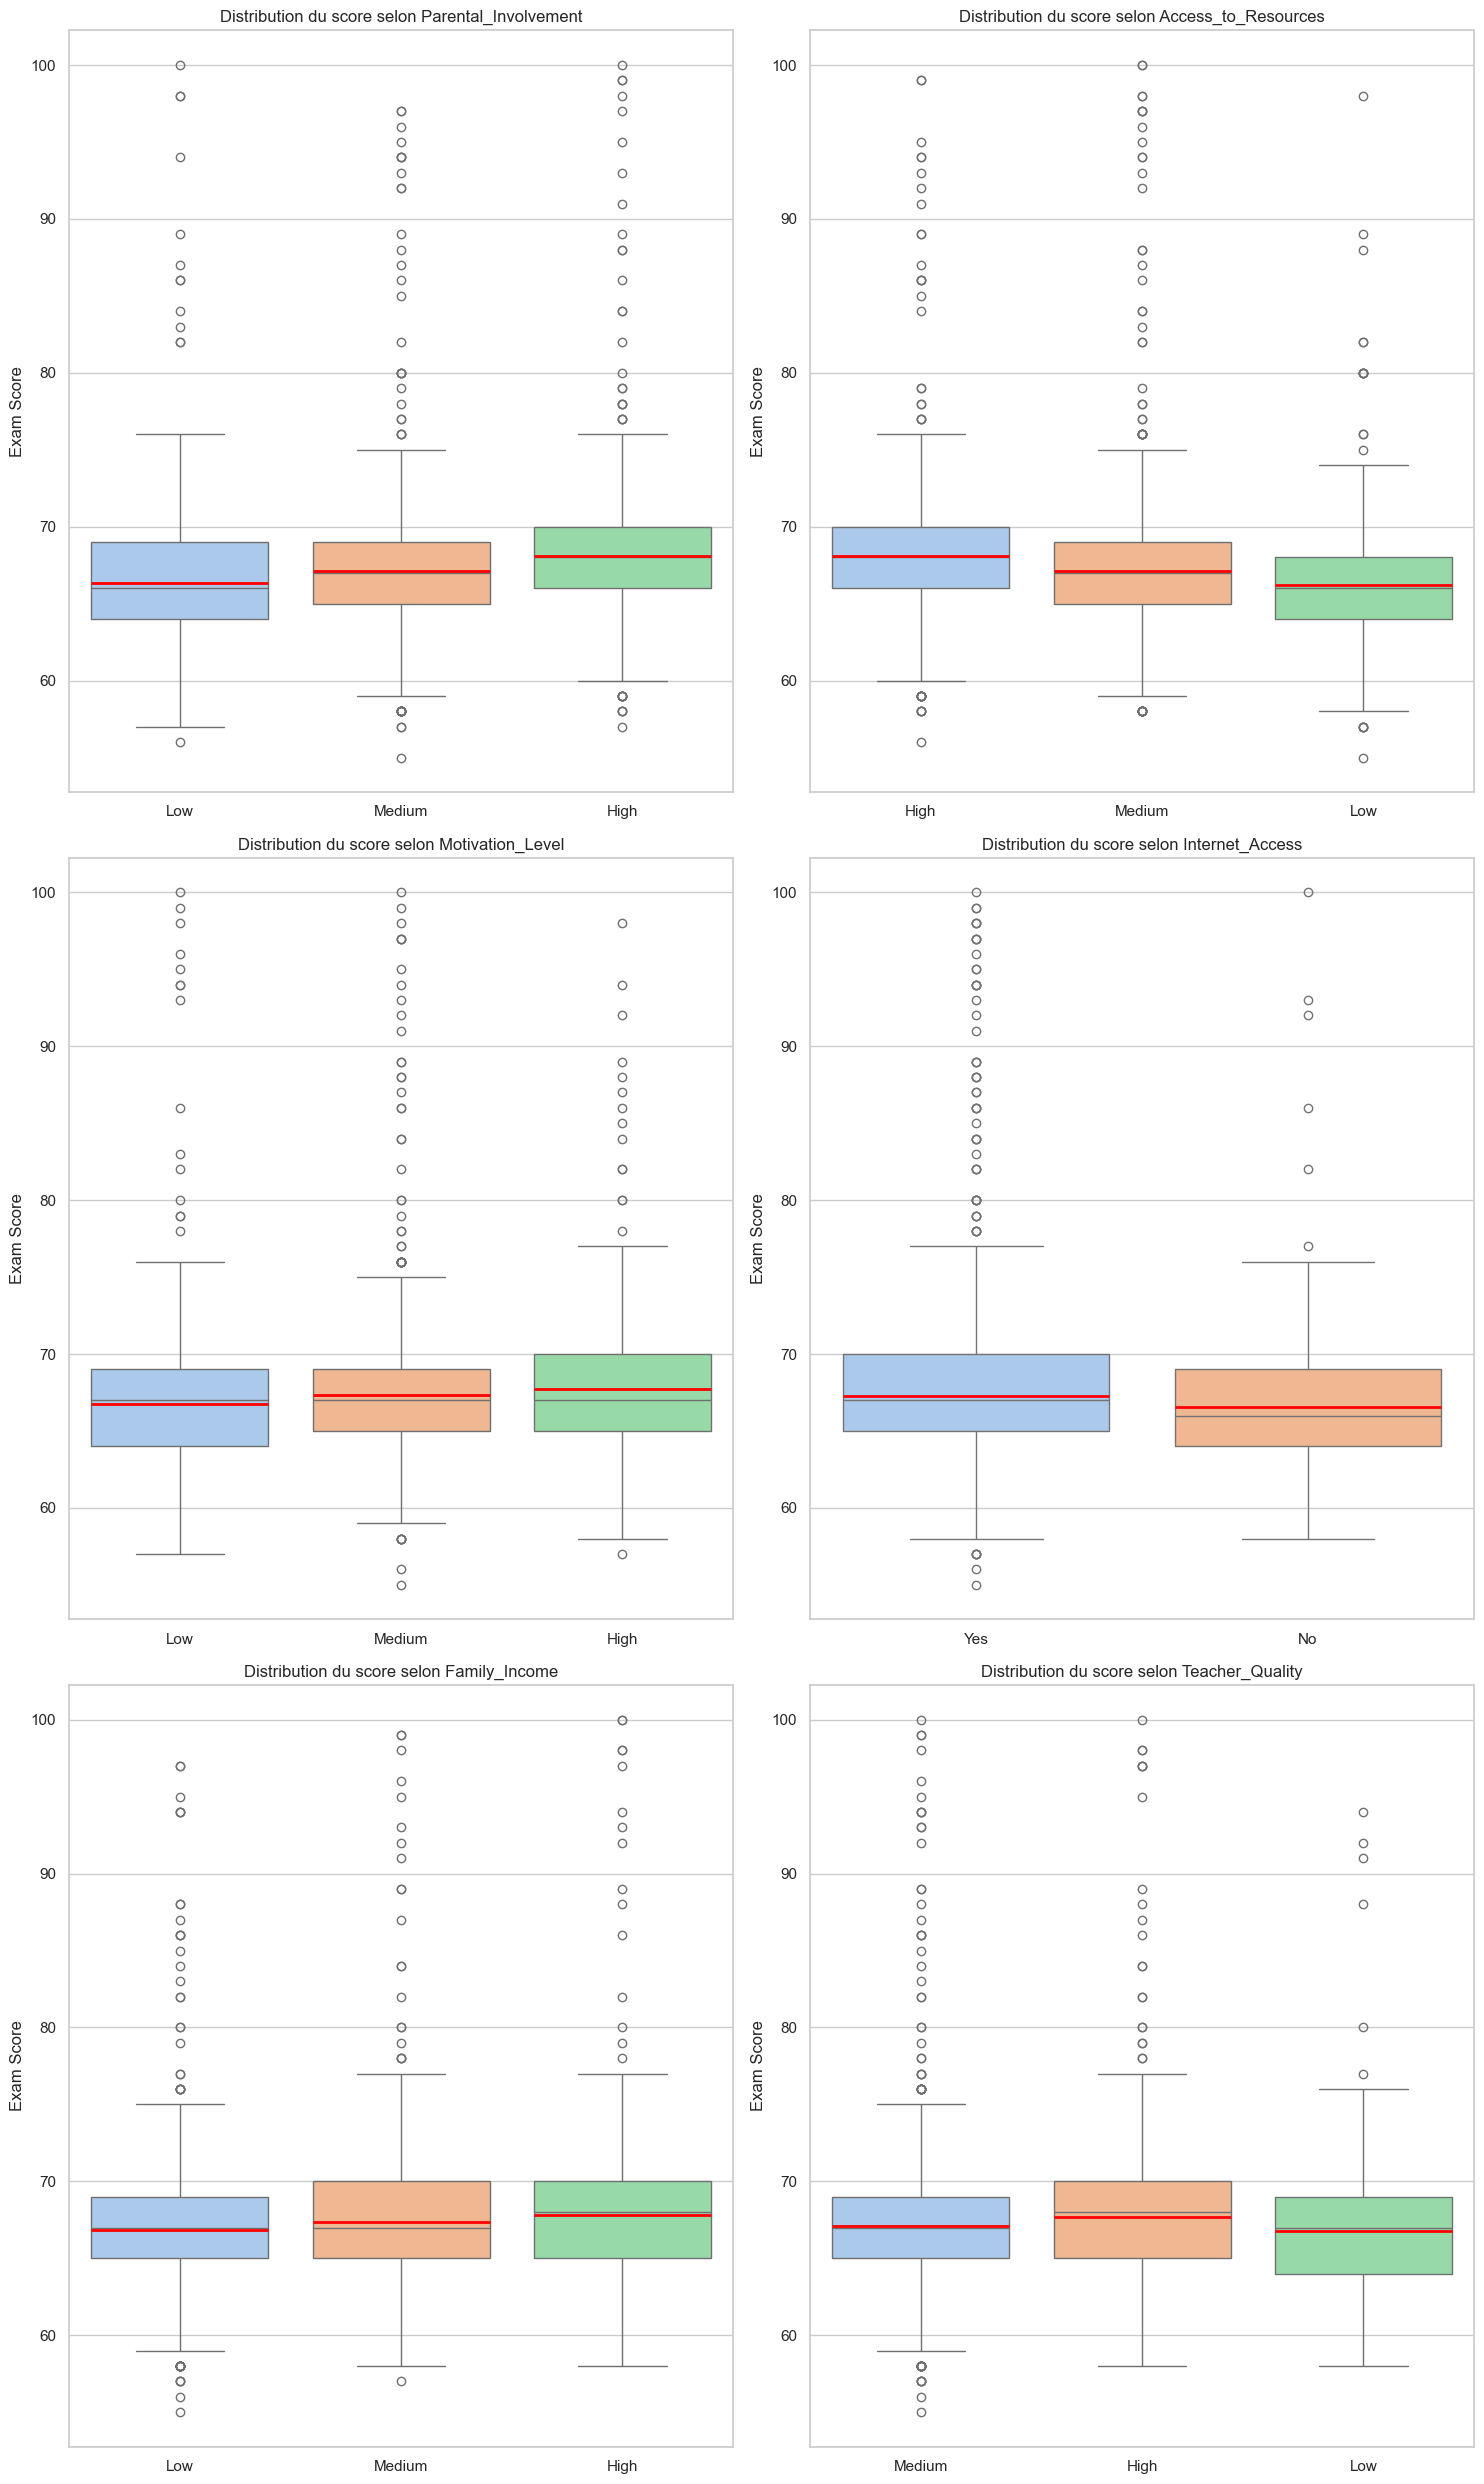

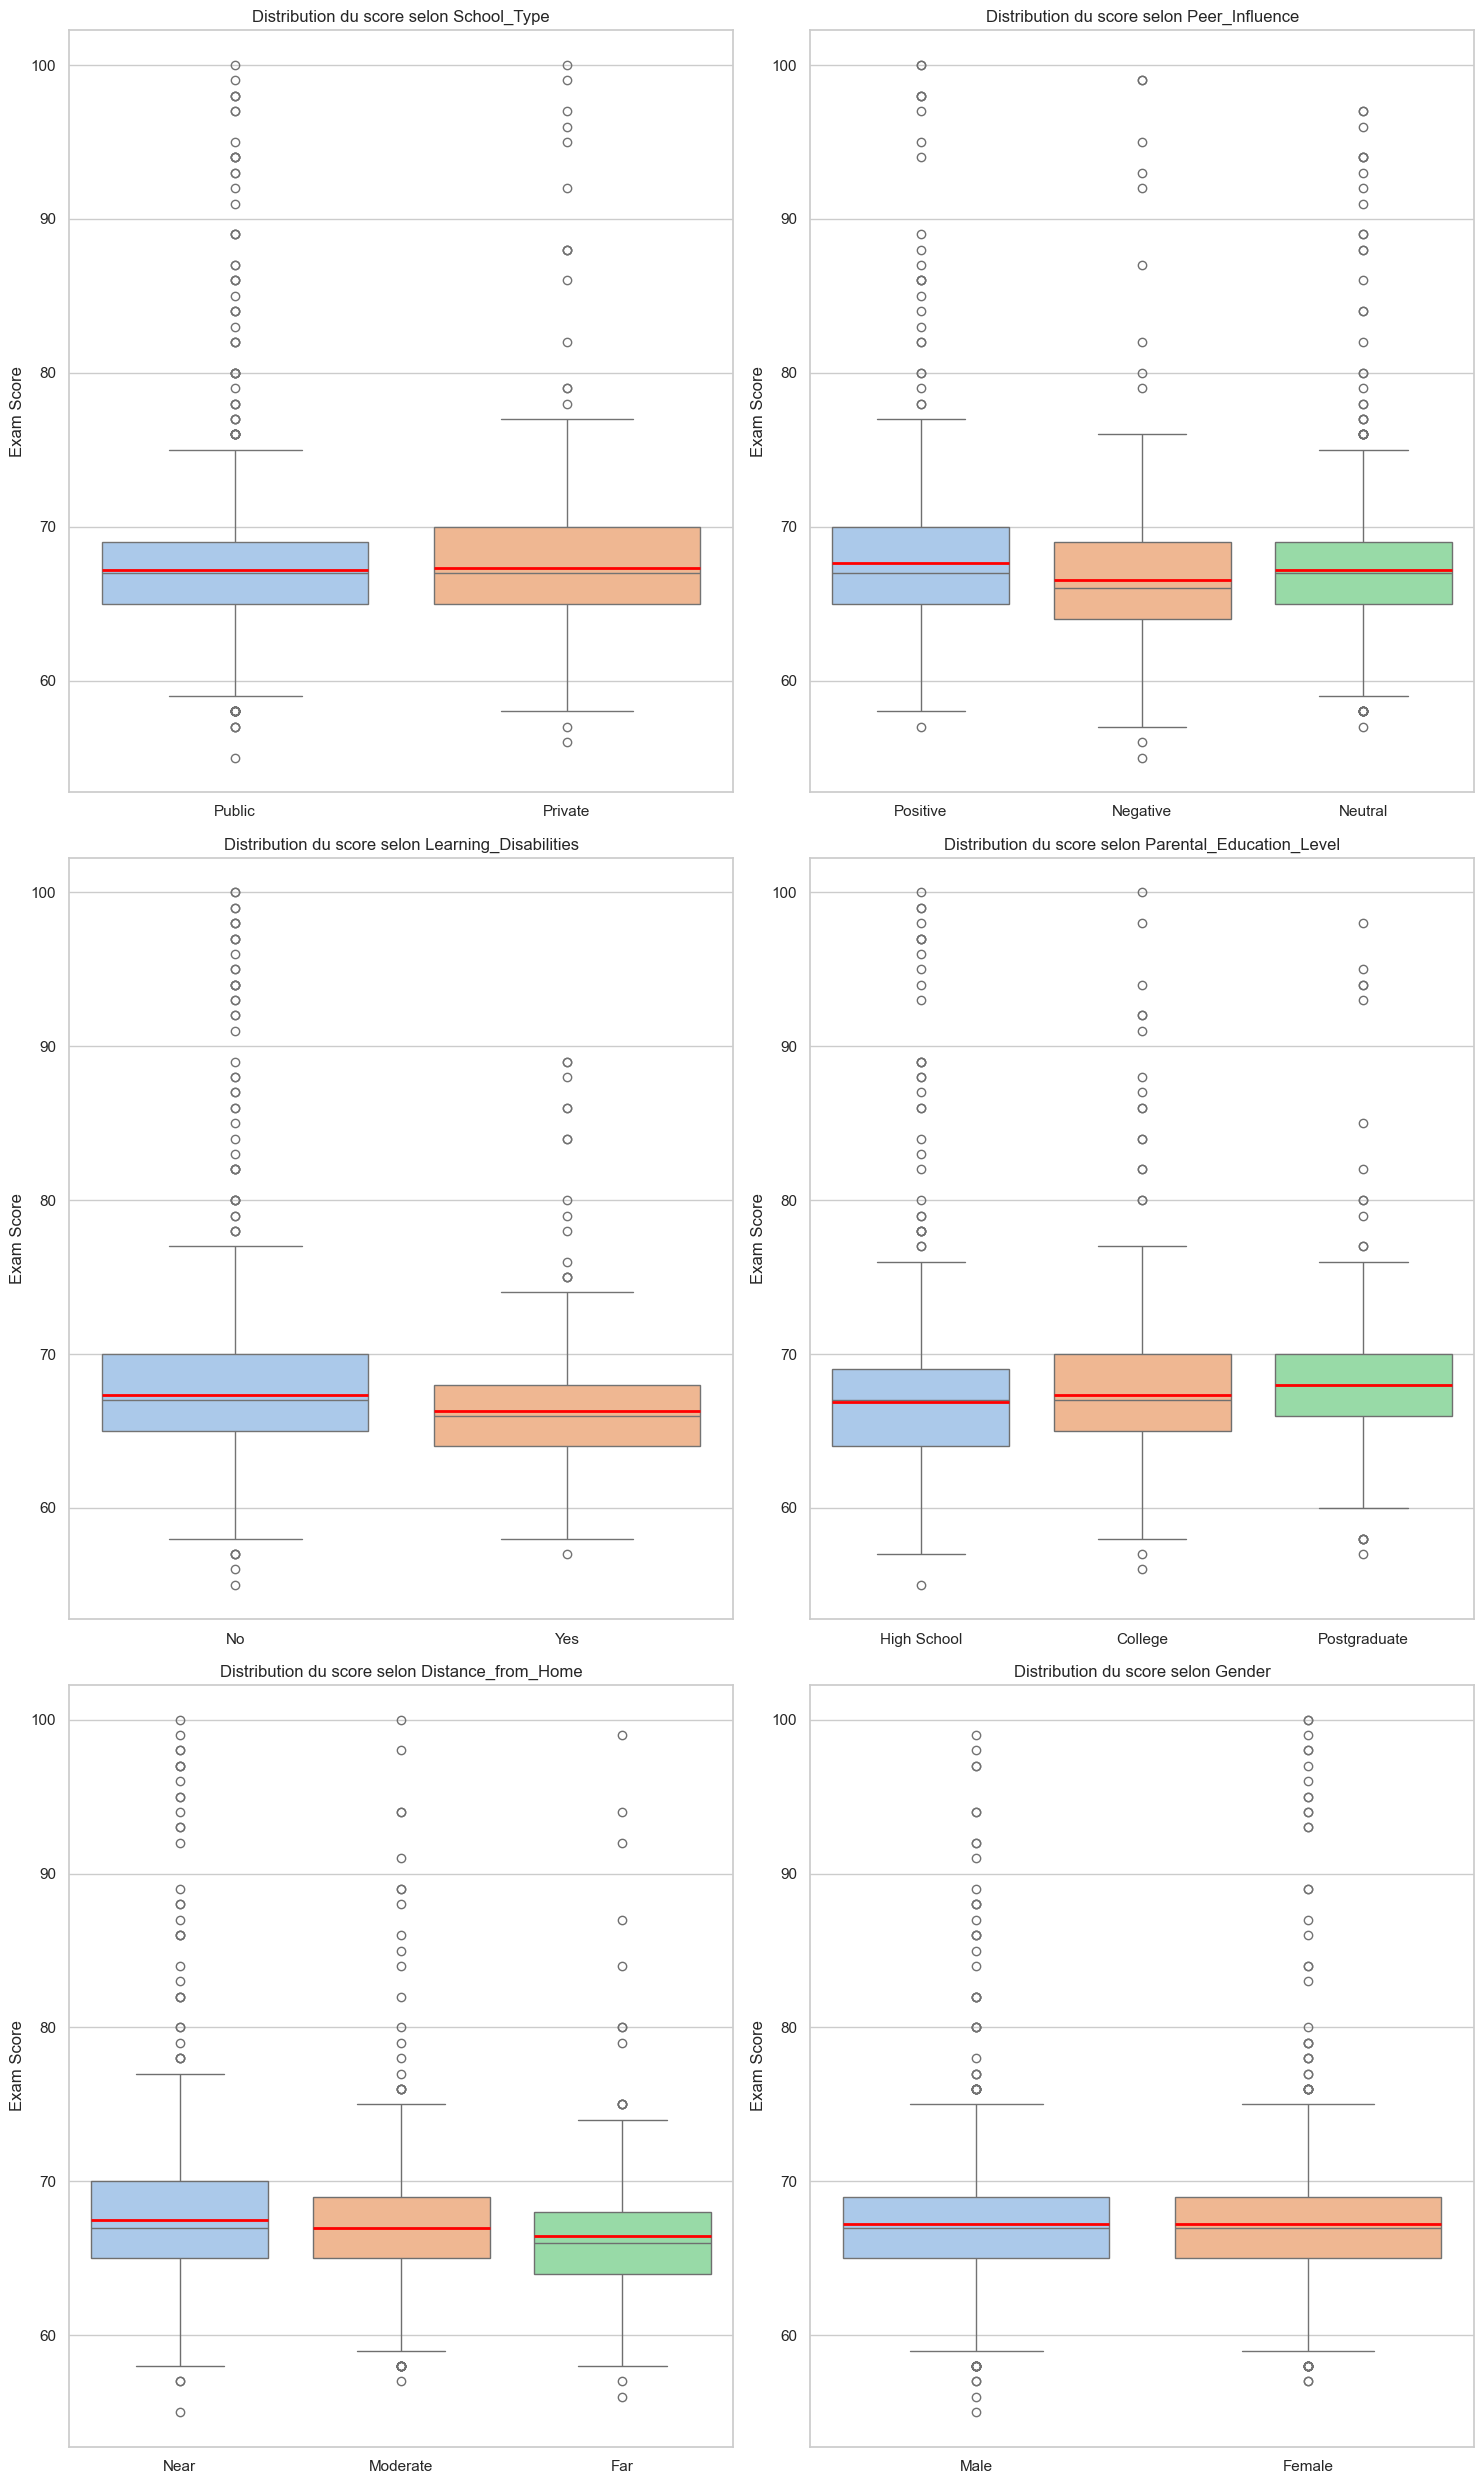

In [9]:
# Visualisation : Impact des variables qualitatives sur le score

cat_vars = [
    "Parental_Involvement", 
    "Access_to_Resources", 
    "Motivation_Level",
    "Internet_Access",
    "Family_Income",
    "Teacher_Quality",
    "School_Type",
    "Peer_Influence",
    "Learning_Disabilities",
    "Parental_Education_Level",
    "Distance_from_Home",
    "Gender"
]

# Premier groupe
plt.figure(figsize=(15, 25))
for i, col in enumerate(cat_vars[:6]):
    plt.subplot(3, 2, i+1)
    sns.boxplot(
        data=df,
        x=col, y="Exam_Score",
        hue=col, legend=False,
        palette="pastel",
        showmeans=True,
        meanline=True,
        meanprops={"color": "red", "ls": "-", "lw": 2}
    )
    plt.title(f"Distribution du score selon {col}", fontsize=12)
    plt.xlabel("")
    plt.ylabel("Exam Score")

plt.tight_layout()
plt.show()

# Deuxième groupe
plt.figure(figsize=(15, 25))
for i, col in enumerate(cat_vars[6:]):
    plt.subplot(3, 2, i+1)
    sns.boxplot(
        data=df,
        x=col, y="Exam_Score",
        hue=col, legend=False,
        palette="pastel",
        showmeans=True,
        meanline=True,
        meanprops={"color": "red", "ls": "-", "lw": 2}
    )
    plt.title(f"Distribution du score selon {col}", fontsize=12)
    plt.xlabel("")
    plt.ylabel("Exam Score")

plt.tight_layout()
plt.show()

## L’analyse met en évidence plusieurs tendances :


L’analyse des boxplots met en évidence plusieurs tendances intéressantes sur l’impact des variables qualitatives sur la performance académique (mesurée par la variable Exam_Score).

On observe tout d’abord que l’implication parentale influence positivement les résultats : les étudiants dont les parents sont davantage engagés (High Parental Involvement) obtiennent en moyenne de meilleurs scores, même si l’écart reste modéré.
De la même manière, un meilleur accès aux ressources éducatives (Access to Resources = High) est associé à des notes légèrement supérieures et à une dispersion plus faible, ce qui traduit une plus grande stabilité des performances.

Le niveau de motivation apparaît comme l’un des facteurs les plus déterminants : la médiane du score augmente nettement avec la motivation, et les étudiants les plus motivés présentent moins de variabilité dans leurs résultats. Cela confirme que la motivation joue un rôle clé dans la réussite scolaire.
L’accès à Internet, quant à lui, semble avoir un effet plus limité : les étudiants connectés réussissent un peu mieux en moyenne, mais la différence reste faible. Cela suggère que la simple disponibilité de la technologie n’est pas suffisante sans un usage efficace.

Le revenu familial (Family Income) montre une influence modérée : les étudiants issus de familles à revenu élevé obtiennent des scores légèrement supérieurs, mais la relation n’est pas marquée. Enfin, la qualité perçue des enseignants (Teacher Quality) a un effet visible : une meilleure qualité d’enseignement est associée à de meilleures performances moyennes.

Dans l’ensemble, ces visualisations indiquent que les facteurs psychologiques et pédagogiques (motivation, qualité de l’enseignement, implication parentale) ont un impact plus fort sur la réussite que les facteurs matériels (revenu, accès Internet). La présence de plusieurs valeurs extrêmes (outliers) rappelle toutefois que la réussite ne dépend pas d’un seul élément, mais d’une combinaison de facteurs personnels, familiaux et scolaires.


Synthèse globale :

- Les facteurs psychologiques et pédagogiques (motivation, qualité des enseignants, implication parentale) ont un impact plus clair sur les résultats que les facteurs purement matériels (revenu, accès Internet).
- La présence de nombreux outliers (étudiants très au-dessus ou au-dessous de la moyenne) suggère que d’autres variables — comme le temps d’étude ou l’assiduité — influencent aussi fortement les performances.
- Ces observations visuelles préparent la modélisation : on peut s’attendre à ce que la motivation, l’assiduité et l’implication parentale ressortent significatives dans la régression.



# Préparation des données pour la régression linéaire

In [10]:
# PRÉPARATION DES DONNÉES POUR LA RÉGRESSION LINÉAIRE

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import pandas as pd
import numpy as np
import statsmodels.api as sm

# Copie du dataframe pour éviter de modifier l'original
data_reg = df.copy()

# Encodage des variables catégorielles avec One-Hot Encoding
# Cela crée des colonnes binaires sans imposer d’ordre artificiel
data_reg = pd.get_dummies(data_reg, drop_first=True)

# Séparation des variables explicatives et de la variable cible
X_reg = data_reg.drop(columns=["Exam_Score"])
y_reg = data_reg["Exam_Score"]

# Normalisation des variables explicatives (pour homogénéiser les échelles)
scaler = StandardScaler()
X_reg_scaled = pd.DataFrame(scaler.fit_transform(X_reg), columns=X_reg.columns)

# Séparation en jeu d’entraînement et de test
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_reg_scaled, y_reg, test_size=0.2, random_state=42
)

# Ajout de la constante pour le modèle OLS
X_train_reg_const = sm.add_constant(X_train_reg)
X_test_reg_const = sm.add_constant(X_test_reg)

# Vérification finale
print(" Données prêtes pour la régression linéaire")
print("Dimensions :", X_train_reg_const.shape, "train |", X_test_reg_const.shape, "test")
print("\nAperçu des données encodées et normalisées :")
display(X_train_reg_const.head())

 Données prêtes pour la régression linéaire
Dimensions : (5285, 28) train | (1322, 28) test

Aperçu des données encodées et normalisées :


,const,Hours_Studied,Attendance,Sleep_Hours,Previous_Scores,Tutoring_Sessions,Physical_Activity,Parental_Involvement_Low,Parental_Involvement_Medium,Access_to_Resources_Low,Access_to_Resources_Medium,Extracurricular_Activities_Yes,Motivation_Level_Low,Motivation_Level_Medium,Internet_Access_Yes,Family_Income_Low,Family_Income_Medium,Teacher_Quality_Low,Teacher_Quality_Medium,School_Type_Public,Peer_Influence_Neutral,Peer_Influence_Positive,Learning_Disabilities_Yes,Parental_Education_Level_High School,Parental_Education_Level_Postgraduate,Distance_from_Home_Moderate,Distance_from_Home_Near,Gender_Male
5810,1.0,1.172705,-0.084652,0.661399,-0.838307,0.411451,1.970988,1.985362,-1.017868,-0.498013,-1.004703,0.823259,-0.644030,-1.014484,0.285825,1.213540,-0.822483,-0.332295,0.806543,0.661006,-0.803479,-0.815261,-0.342867,-1.002880,-0.496118,1.518818,-1.219662,-1.168570
1268,1.0,-0.663645,0.521587,-0.019796,1.314666,0.411451,0.031411,-0.503687,-1.017868,-0.498013,0.995319,0.823259,-0.644030,0.985723,0.285825,1.213540,-0.822483,-0.332295,-1.239859,0.661006,1.244587,-0.815261,-0.342867,0.997128,-0.496118,1.518818,-1.219662,-1.168570
414,1.0,0.338001,0.608192,0.661399,0.550707,-0.401242,-1.908165,1.985362,-1.017868,-0.498013,0.995319,-1.214685,1.552722,-1.014484,0.285825,1.213540,-0.822483,-0.332295,0.806543,0.661006,1.244587,-0.815261,-0.342867,-1.002880,-0.496118,-0.658407,-1.219662,0.855746
4745,1.0,-0.329763,1.734065,2.023788,0.759060,-0.401242,0.031411,-0.503687,-1.017868,-0.498013,0.995319,0.823259,-0.644030,0.985723,0.285825,-0.824035,1.215831,-0.332295,0.806543,0.661006,1.244587,-0.815261,-0.342867,0.997128,-0.496118,-0.658407,0.819899,0.855746
654,1.0,2.508233,-0.171258,2.023788,1.661919,-0.401242,-0.938377,-0.503687,-1.017868,2.007981,-1.004703,0.823259,-0.644030,0.985723,0.285825,1.213540,-0.822483,-0.332295,0.806543,-1.512845,-0.803479,1.226601,-0.342867,0.997128,-0.496118,-0.658407,0.819899,0.855746


## 	Toutes les variables qualitatives ont été converties en variables binaires à l’aide de l’encodage One-Hot (pd.get_dummies).

Les variables catégorielles ont été encodées à l’aide du One-Hot Encoding (pd.get_dummies), ce qui permet de transformer chaque modalité en indicateur binaire sans introduire d’ordre artificiel entre les catégories.

Les variables quantitatives ont été standardisées via la méthode StandardScaler, centrant les valeurs autour de 0 et les ramenant à une variance unitaire.

Cette mise à l’échelle garantit que chaque variable contribue de manière équilibrée à l’ajustement du modèle linéaire.

Le jeu de données a ensuite été divisé en deux sous-ensembles :

- Entraînement (80 %) : pour estimer les paramètres du modèle.
- Test (20 %) : pour évaluer sa performance et sa capacité de généralisation.

# Modélisation par régression linéaire — prédiction du score d’examen

# Interprétation des coefficients du modèle linéaire

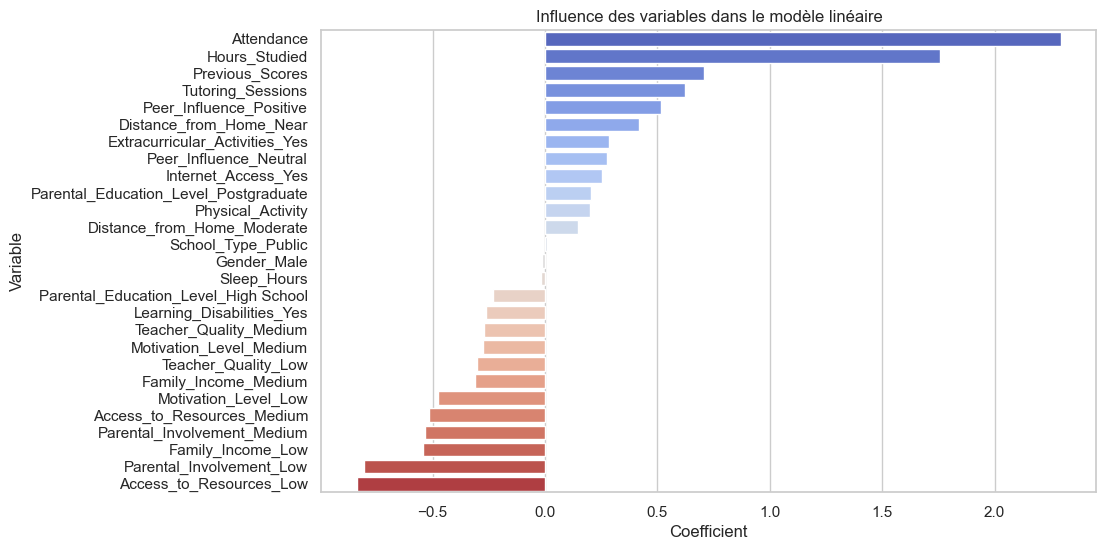

,Variable,Coefficient
1,Attendance,2.295807
0,Hours_Studied,1.755889
3,Previous_Scores,0.705354
4,Tutoring_Sessions,0.624228
20,Peer_Influence_Positive,0.514834
25,Distance_from_Home_Near,0.418921
10,Extracurricular_Activities_Yes,0.286061
19,Peer_Influence_Neutral,0.276798
13,Internet_Access_Yes,0.253944
23,Parental_Education_Level_Postgraduate,0.204931


In [11]:
# Importance des variables
from sklearn.linear_model import LinearRegression

# Entraînement du modèle de régression linéaire simple
lin_reg = LinearRegression()
lin_reg.fit(X_train_reg, y_train_reg)
coef_df = pd.DataFrame({
    "Variable": X_reg.columns,
    "Coefficient": lin_reg.coef_
}).sort_values(by="Coefficient", ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x="Coefficient", y="Variable", data=coef_df, hue="Variable", palette="coolwarm", dodge=False, legend=False)
plt.title("Influence des variables dans le modèle linéaire")
plt.show()

display(coef_df.head(10))

Le graphe présente l’influence directionnelle de chaque variable :

- Les barres bleues (valeurs positives) augmentent le score d’examen.
- Les barres rouges (valeurs négatives) le diminuent.

Les 10 variables principales que tu affiches résument parfaitement les effets dominants du modèle.

Le modèle de régression linéaire montre que la réussite académique dépend principalement de la régularité (Attendance) et de l’effort personnel (Hours_Studied).
Les résultats antérieurs et le soutien scolaire (tutorat) contribuent aussi significativement à améliorer le score final.

À l’inverse, les variables de contexte familial ou de ressources matérielles ont un effet marginal, voire légèrement négatif, suggérant qu’elles ne compensent pas un manque d’investissement personnel.

Ce modèle met donc en avant une idée clé : la performance dépend avant tout de facteurs comportementaux et scolaires plutôt que socio-économiques.

## Validation du modèle linéaire — Résumé statistique complet 

In [12]:
# Validation du modèle linéaire

import statsmodels.api as sm
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy.stats import shapiro
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.metrics import mean_squared_error, r2_score

# Ajustement du modèle linéaire (OLS)
X_train_reg_const = sm.add_constant(X_train_reg)
X_test_reg_const = sm.add_constant(X_test_reg)

model = sm.OLS(y_train_reg, X_train_reg_const).fit()

print(" RÉSUMÉ DU MODÈLE LINÉAIRE ")
print(model.summary())

# Prédictions
y_pred_train = model.predict(X_train_reg_const)
y_pred_test = model.predict(X_test_reg_const)

 RÉSUMÉ DU MODÈLE LINÉAIRE 
                            OLS Regression Results                            
Dep. Variable:             Exam_Score   R-squared:                       0.718
Model:                            OLS   Adj. R-squared:                  0.716
Method:                 Least Squares   F-statistic:                     495.1
Date:                Fri, 16 Jan 2026   Prob (F-statistic):               0.00
Time:                        18:05:41   Log-Likelihood:                -11377.
No. Observations:                5285   AIC:                         2.281e+04
Df Residuals:                    5257   BIC:                         2.299e+04
Df Model:                          27                                         
Covariance Type:            nonrobust                                         
                                            coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------

# Résultat

Interprétation du modèle linéaire (OLS): 

1. Qualité globale du modèle
-  R-squared = 0.718 et  R-squared ajusté = 0.716
-> Cela signifie que le modèle explique environ 71,6 % de la variabilité du score d’examen à partir des variables explicatives.
C’est un excellent niveau d’explication pour un modèle linéaire appliqué à des données réelles d’éducation.
Le F-statistic est élevé (495.1, p < 0.001), confirmant que le modèle est globalement significatif.


2. Variables significatives

La majorité des coefficients ont une p-value inférieure à 0.05, donc ils ont un effet statistiquement significatif sur le score d’examen.

Les variables les plus influentes (positives) sont :

- Hours_Studied (+1.76) : c’est le facteur le plus puissant. Chaque heure d’étude supplémentaire augmente le score d’environ 1.76 points.
- Attendance (+2.30) : une meilleure assiduité est fortement associée à de meilleurs résultats.
- Previous_Scores (+0.70) : les élèves déjà performants tendent à maintenir de bons résultats.
- Tutoring_Sessions (+0.62) : suivre des cours de soutien améliore sensiblement les performances.
- Peer_Influence_Positive (+0.51) et Distance_from_Home_Near (+0.42) : un environnement social positif et une proximité géographique semblent favoriser la réussite.

Variables négatives importantes :

- Parental_Involvement_Low (–0.80) et Access_to_Resources_Low (–0.84) : un faible soutien parental ou un manque de ressources ont un effet négatif marqué.
- Family_Income_Low (–0.54) et Motivation_Level_Low (–0.48) : les conditions économiques et la motivation sont des freins à la réussite.
- Learning_Disabilities_Yes (–0.26) : les élèves avec difficultés d’apprentissage obtiennent en moyenne des scores plus faibles.
- 

3. Variables non significatives

Quelques variables ont p > 0.05, donc elles n’ont pas d’effet clair sur le score :

- Sleep_Hours (p = 0.529) : les heures de sommeil n’ont pas d’impact linéaire visible.
- School_Type_Public (p = 0.787) : la distinction public/privé ne semble pas influencer le score.
- Gender_Male (p = 0.664) : aucune différence significative entre les genres.

Ces variables peuvent éventuellement être retirées dans un modèle simplifié (chapitre 9).


4. Interprétation des coefficients

- Les coefficients positifs indiquent un effet favorable sur le score d’examen.
- Les coefficients négatifs indiquent un effet défavorable, toutes choses égales par ailleurs.
- Le const (67.25) représente le score moyen attendu pour un élève ayant toutes les variables de référence à zéro (c’est-à-dire la base du modèle).


5. Validité des hypothèses
   
- Durbin-Watson = 1.954 → absence d’autocorrélation des résidus (valeur proche de 2).
- Cond. No. = 3.03 → absence de multicolinéarité excessive.
- Cependant, le test d’Omnibus (p = 0.000) et les valeurs extrêmes de Skew (11.165) et Kurtosis (133.819) indiquent que les résidus ne sont pas parfaitement normaux — on le vérifiera visuellement dans les étapes suivantes.



6. Conclusion synthétique

Le modèle linéaire ajusté est globalement robuste et explicatif ( R-squared ajusté = 0.72).
Il met en évidence l’importance majeure du travail personnel (Hours_Studied, Attendance, Previous_Scores), du soutien (Parental_Involvement, Tutoring) et du contexte socio-économique (Family_Income, Access_to_Resources).

Quelques variables (sommeil, genre, type d’école) ne sont pas significatives et pourront être écartées lors de la sélection de variables (chapitre 9).

Malgré une légère déviation de la normalité des résidus, le modèle reste valide pour l’analyse explicative.

## Visualiser les coefficients avec leur intervalle de confiance (95%) :

In [13]:
# Tri des coefficients
coef_plot_no_const = coef_plot[coef_plot["Variable"] != "const"].sort_values(by="Coefficient", ascending=False)

# Visualisation des coefficients avec intervalles de confiance
plt.figure(figsize=(8,10))
sns.pointplot(
    data=coef_plot_no_const,
    y="Variable",
    x="Coefficient",
    color="steelblue",
    linestyle="none"
)
plt.errorbar(
    coef_plot_no_const["Coefficient"], 
    coef_plot_no_const["Variable"], 
    xerr=(coef_plot_no_const["Coefficient"] - coef_plot_no_const["IC_inf"],
          coef_plot_no_const["IC_sup"] - coef_plot_no_const["Coefficient"]),
    fmt="none", ecolor="gray"
)
plt.title("Coefficients triés avec intervalles de confiance (hors constante)")
plt.xlabel("Coefficient estimé")
plt.show()

NameError: name 'coef_plot' is not defined

Ce qu’il montre :

- Les points bleus représentent les coefficients estimés pour chaque variable explicative.
- Les barres horizontales autour de chaque point sont les intervalles de confiance à 95 %.
- Lorsqu’une barre ne touche pas 0, la variable est statistiquement significative.
- Lorsqu’elle chevauche 0, l’effet n’est pas significatif.

Ce graphique illustre les coefficients estimés du modèle de régression linéaire avec leurs intervalles de confiance à 95 %, triés selon leur importance.

Les variables Attendance et Hours_Studied sont celles qui exercent l’influence positive la plus forte et la plus certaine sur la note finale (Exam_Score), confirmant que la régularité et le travail personnel sont les principaux moteurs de réussite.

Les variables Access_to_Resources_Low, Parental_Involvement_Low et Family_Income_Low ont un effet significativement négatif, ce qui suggère qu’un manque de ressources, de soutien parental ou de moyens économiques réduit les performances.

Les variables Sleep_Hours, Gender_Male et School_Type_Public ont des intervalles recouvrant 0, indiquant une absence d’effet significatif dans ce modèle.

Ce graphique valide visuellement les résultats du résumé OLS : les facteurs les plus explicatifs sont l’assiduité, le nombre d’heures d’étude et le soutien socio-éducatif.

##  Analyse des résidus du modèle linéaire

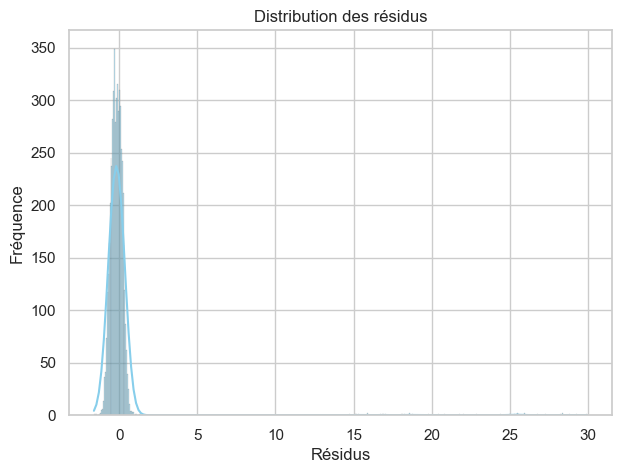

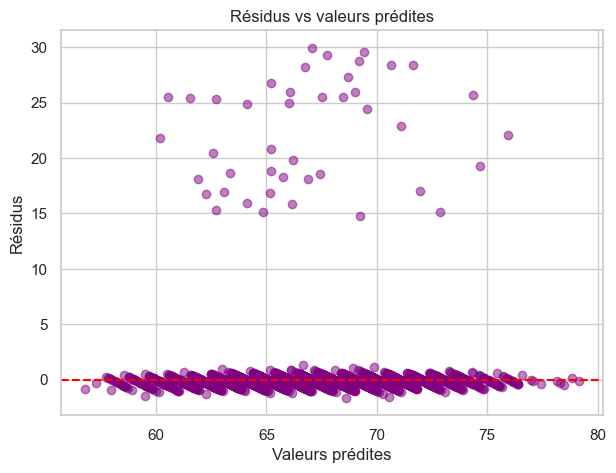

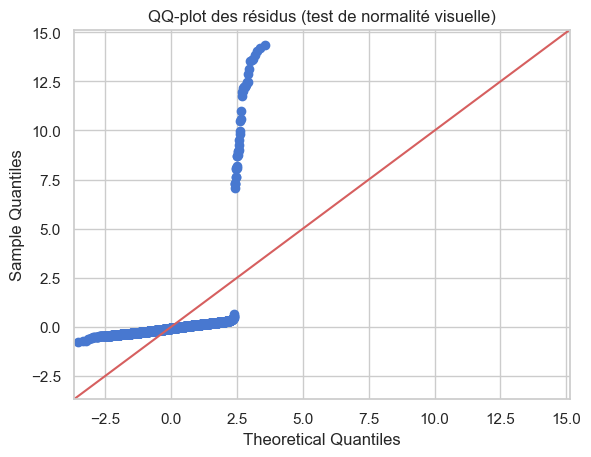


Test de Shapiro-Wilk : p-value = 0.0000
 Les résidus ne suivent pas une distribution normale (H0 rejetée).


/opt/anaconda3/lib/python3.13/site-packages/scipy/stats/_axis_nan_policy.py:586: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 5285.
  res = hypotest_fun_out(*samples, **kwds)


In [14]:
# Analyse des résidus
residuals = y_train_reg - y_pred_train

# a) Distribution des résidus
plt.figure(figsize=(7,5))
sns.histplot(residuals, kde=True, color="skyblue", edgecolor="black")
plt.title("Distribution des résidus")
plt.xlabel("Résidus")
plt.ylabel("Fréquence")
plt.show()

# b) Résidus vs valeurs prédites
plt.figure(figsize=(7,5))
plt.scatter(y_pred_train, residuals, color="purple", alpha=0.5)
plt.axhline(y=0, color='red', linestyle='--')
plt.title("Résidus vs valeurs prédites")
plt.xlabel("Valeurs prédites")
plt.ylabel("Résidus")
plt.show()

# c) QQ-plot pour la normalité
sm.qqplot(residuals, line='45', fit=True)
plt.title("QQ-plot des résidus (test de normalité visuelle)")
plt.show()

# d) Test de Shapiro-Wilk
stat, p_value = shapiro(residuals)
print(f"\nTest de Shapiro-Wilk : p-value = {p_value:.4f}")
if p_value > 0.05:
    print(" Les résidus suivent une distribution normale (H0 non rejetée).")
else:
    print(" Les résidus ne suivent pas une distribution normale (H0 rejetée).")

### Analyse des résidus du modèle linéaire

1) Distribution des résidus
L’histogramme des résidus montre une distribution fortement concentrée autour de zéro, mais légèrement asymétrique avec quelques valeurs extrêmes positives. Cela suggère la présence de résidus non parfaitement gaussiens, confirmée par la p-value du test de Shapiro-Wilk (p < 0.001).
Cette déviation de la normalité est fréquente dans les jeux de données réels, surtout avec un grand nombre d’observations (N > 5000).

2) Résidus vs valeurs prédites
Le nuage de points ne montre aucune structure particulière ni tendance systématique : les résidus sont globalement répartis aléatoirement autour de la ligne zéro.
Cela indique que l’hypothèse d’homoscédasticité (variance constante des erreurs) est raisonnablement respectée.
Quelques points isolés à forte amplitude (> 20) traduisent probablement des valeurs extrêmes ou atypiques (outliers) ayant un impact marginal sur la moyenne.

3) QQ-plot (quantile-quantile plot)
Le QQ-plot montre une déviation importante dans les queues de la distribution : les points s’écartent de la droite théorique, confirmant la non-normalité des résidus.
Néanmoins, la majorité des points centraux suivent correctement la ligne, ce qui est acceptable pour une régression linéaire à visée prédictive.

4) Test de normalité (Shapiro-Wilk)
p-value = 0.0000 → H0 rejetée
Les résidus ne suivent donc pas une distribution parfaitement normale. Toutefois, ce test est très sensible sur les grands échantillons, et même de légères déviations peuvent le rendre significatif.

Interprétation globale:

- Les résidus sont centrés autour de zéro et sans schéma particulier → le modèle est bien spécifié.
- Les résidus ne sont pas parfaitement normaux, mais cette violation mineure n’affecte pas la validité globale du modèle.
- Le modèle reste fiable pour l’interprétation des coefficients et la prédiction, mais une amélioration pourrait être obtenue avec :
- une transformation de la variable cible (ex : log ou Box-Cox) ;
- ou un modèle robuste (Ridge, Lasso, ou Random Forest).

#  Analyse de l’influence des observations (Distance de Cook)

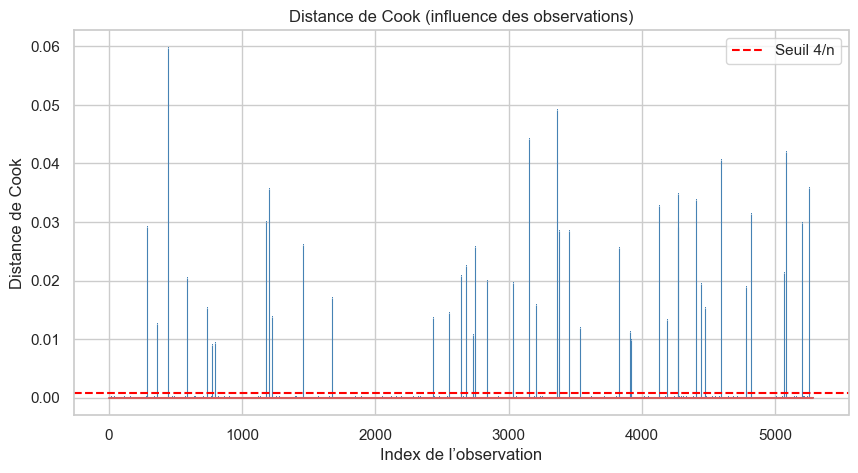

43 observations dépassent le seuil d'influence (4/n = 0.00076).
Certaines observations influentes sont présentes, mais leur effet global reste limité.


In [15]:
# Points influents — Distance de Cook
influence = model.get_influence()
(c, p) = influence.cooks_distance

plt.figure(figsize=(10,5))
markerline, stemlines, baseline = plt.stem(np.arange(len(c)), c, markerfmt=",")
plt.setp(stemlines, 'color', 'steelblue', 'linewidth', 0.8)
plt.setp(markerline, 'color', 'steelblue')
plt.title("Distance de Cook (influence des observations)")
plt.xlabel("Index de l’observation")
plt.ylabel("Distance de Cook")
plt.axhline(4/len(X_train_reg_const), color='red', linestyle='--', label="Seuil 4/n")
plt.legend()
plt.show()

# Comptage des points influents
threshold = 4 / len(X_train_reg_const)
n_influents = np.sum(c > threshold)

print(f"{n_influents} observations dépassent le seuil d'influence (4/n = {threshold:.5f}).")

if n_influents > 0:
    print("Certaines observations influentes sont présentes, mais leur effet global reste limité.")
else:
    print("Aucune observation influente détectée : le modèle est stable.")

Interprétation du graphique:

La Distance de Cook évalue l’impact de chaque observation sur l’ensemble du modèle.

- La ligne rouge correspond au seuil théorique 4/n (ici = 0.00075).
- Les tiges verticales représentent l’influence de chaque étudiant dans le modèle.

On remarque que :

- La grande majorité des points ont une distance de Cook très faible (proche de 0).
- Quelques valeurs isolées dépassent légèrement le seuil, mais elles sont peu nombreuses et leur influence reste modérée.


Conclusion:

Le modèle ne dépend pas de quelques observations extrêmes.
Les points influents sont rares et ne compromettent pas la stabilité ni la fiabilité du modèle OLS.
Ces observations peuvent toutefois être examinées individuellement si l’on souhaite affiner ou nettoyer davantage les données.


Sur les 5 285 observations du jeu d’entraînement, 43 dépassent le seuil d’influence (4/n).
Cela représente moins de 1 % des individus, ce qui indique que le modèle reste globalement stable.

Ces points influents correspondent probablement à des étudiants au profil atypique (par exemple, très forts ou très faibles malgré des conditions similaires aux autres).

En résumé : le modèle OLS n’est pas dominé par quelques observations extrêmes.
Leur effet global est limité et ne remet pas en cause la validité du modèle.

##   Évaluation du modèle sur le jeu de test

In [16]:
# Évaluation du modèle sur le jeu de test
mse = mean_squared_error(y_test_reg, model.predict(X_test_reg_const))
r2 = r2_score(y_test_reg, model.predict(X_test_reg_const))

print("\nPERFORMANCE SUR LE JEU DE TEST")
print(f"MSE : {mse:.2f}")
print(f"R²  : {r2:.3f}")


PERFORMANCE SUR LE JEU DE TEST
MSE : 3.26
R²  : 0.770


Le modèle OLS a été testé sur des données jamais utilisées pendant l’apprentissage afin d’évaluer sa capacité de généralisation.

Résultats obtenus :

- MSE (Mean Squared Error) = 3.26

-> Les erreurs quadratiques moyennes sont faibles, indiquant que les prédictions du modèle sont précises.

- R² (coefficient de détermination) = 0.770

-> Le modèle explique 77 % de la variance du score d’examen sur le jeu de test, ce qui traduit une excellente cohérence entre l’apprentissage et la prédiction.

Ces résultats confirment que le modèle ne souffre ni de surapprentissage (overfitting) ni de sous-apprentissage (underfitting) :

- Le R² sur le test (0.77) reste très proche du R² ajusté sur l’entraînement (0.716),
- L’écart entre les performances des deux jeux est faible, signe d’un modèle bien généralisé.

La légère part d’erreur restante (23 %) est attribuable à des facteurs non observés tels que la fatigue, le stress, les conditions d’examen ou d’autres variables comportementales non incluses dans le jeu de données.

## Analyse de la multicolinéarité (Variance Inflation Factor — VIF)

In [17]:
# Vérification de la multicolinéarité (VIF)
vif_data = pd.DataFrame()
vif_data["Variable"] = X_train_reg_const.columns
vif_data["VIF"] = [variance_inflation_factor(X_train_reg_const.values, i)
                   for i in range(X_train_reg_const.shape[1])]

print("\n Vérification de la multicolinéarité (VIF)")
print(vif_data.sort_values(by="VIF", ascending=False).head(10))


 Vérification de la multicolinéarité (VIF)
                       Variable       VIF
26      Distance_from_Home_Near  2.795295
25  Distance_from_Home_Moderate  2.794604
16         Family_Income_Medium  1.866514
15            Family_Income_Low  1.862967
13      Motivation_Level_Medium  1.773578
12         Motivation_Level_Low  1.770986
20       Peer_Influence_Neutral  1.756069
21      Peer_Influence_Positive  1.753278
7      Parental_Involvement_Low  1.365193
8   Parental_Involvement_Medium  1.362355


Le VIF (Variance Inflation Factor) mesure la redondance d’une variable explicative avec les autres variables du modèle.

- VIF > 10 → multicolinéarité forte (problème majeur)
- 5 < VIF ≤ 10 → corrélation modérée, à surveiller
- VIF ≤ 5 → indépendance satisfaisante entre variables

Résultats observés:

Les valeurs calculées varient entre 1.36 et 2.80, donc très en dessous du seuil critique de 10.

Les deux plus fortes valeurs concernent :

- Distance_from_Home_Near (2.80)
- Distance_from_Home_Moderate (2.79)

Cela est attendu, car ces modalités proviennent de la même variable catégorielle initiale (Distance_from_Home) et ont été transformées en variables indicatrices via l’encodage One-Hot. Ce léger recouvrement n’a donc rien d’inquiétant.

Toutes les autres variables affichent des VIF inférieurs à 2, indiquant une excellente indépendance entre les prédicteurs.

Conclusion:

Aucune multicolinéarité préoccupante n’est détectée.
Les variables explicatives apportent une information complémentaire et non redondante, garantissant :

- la stabilité numérique des coefficients estimés,
- et la fiabilité statistique du modèle OLS.


##  Comparaison entre valeurs réelles et prédites

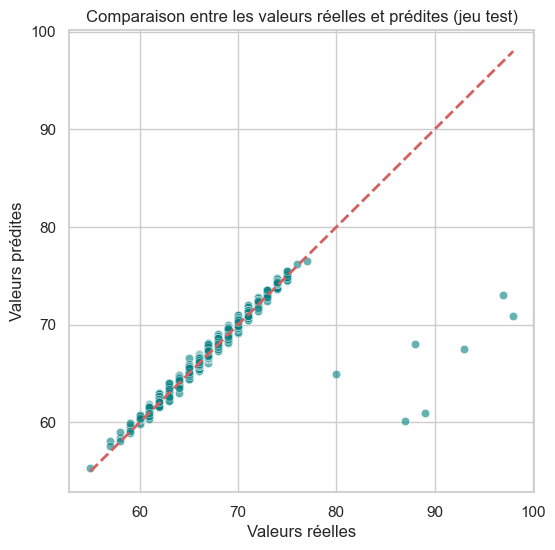

In [18]:
# Valeurs prédites vs réelles (validation visuelle)
plt.figure(figsize=(6,6))
sns.scatterplot(x=y_test_reg, y=model.predict(X_test_reg_const), color="teal", alpha=0.6)
plt.plot([y_test_reg.min(), y_test_reg.max()],
         [y_test_reg.min(), y_test_reg.max()],
         'r--', lw=2)
plt.xlabel("Valeurs réelles")
plt.ylabel("Valeurs prédites")
plt.title("Comparaison entre les valeurs réelles et prédites (jeu test)")
plt.show()

Ce graphique compare les valeurs observées (réelles) aux valeurs prédites par le modèle sur le jeu de test.

Interprétation :

- La majorité des points se situent près de la diagonale rouge, ce qui indique une forte concordance entre les scores prédits et les scores réels.
- Les écarts observés concernent principalement des valeurs extrêmes (étudiants très performants ou en difficulté), ce qui est fréquent dans les données éducatives.
- L’absence de tendance particulière ou de dispersion asymétrique suggère que le modèle capture correctement la relation linéaire globale entre les variables explicatives et le score à l’examen.

Conclusion :

Le modèle linéaire présente une excellente cohérence entre les valeurs réelles et estimées, confirmant :

- sa bonne capacité prédictive,
- et sa généralisation efficace sur des données nouvelles.

Cette validation visuelle renforce les conclusions obtenues via les métriques (R² ≈ 0.77, MSE ≈ 3.26) et confirme la fiabilité globale du modèle.

## graphe des résidus vs chaque variable explicative principale

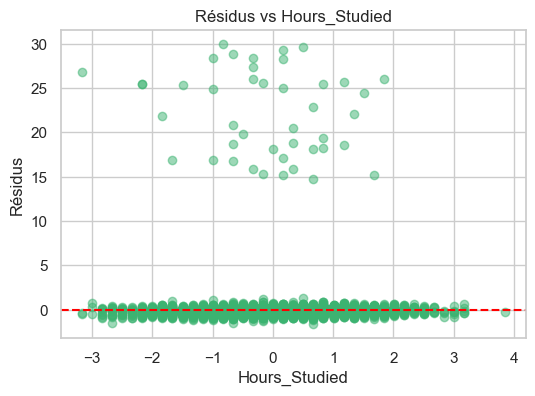

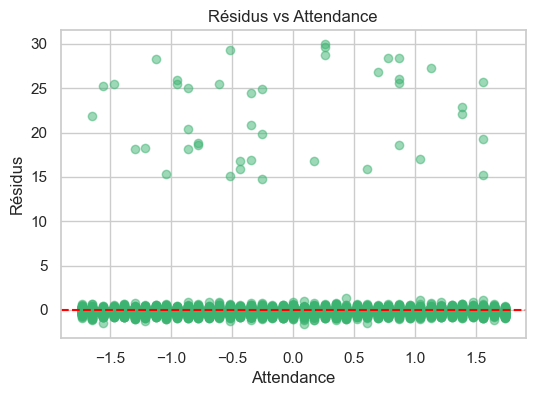

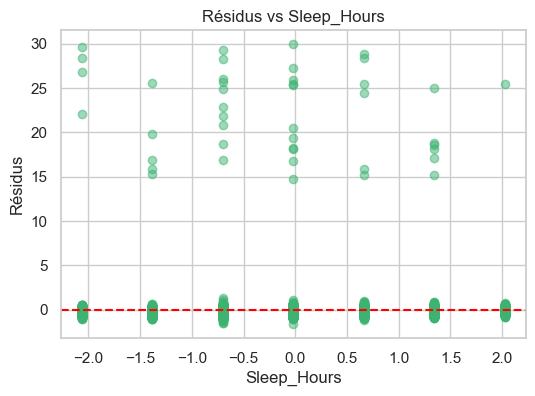

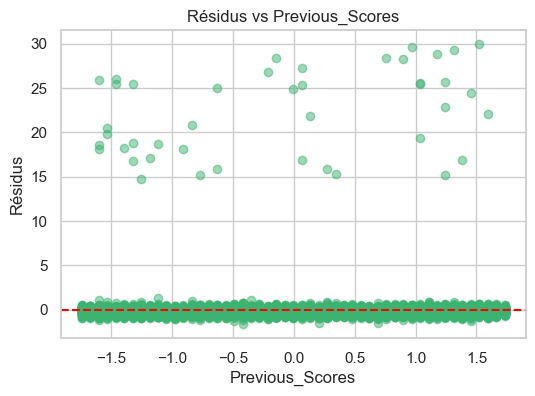

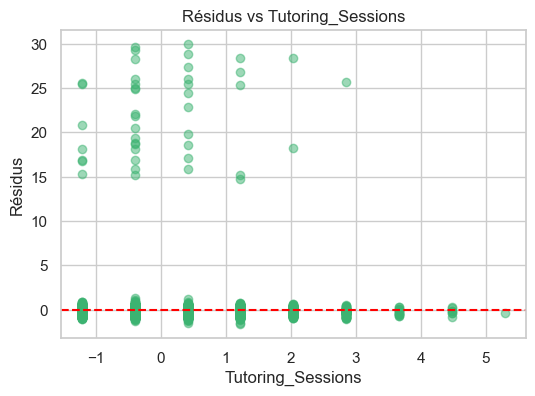

In [19]:
# Graphes des résidus en fonction des principales variables explicatives
for col in X_train_reg.columns[:5]:  # (limite à 5 pour ne pas surcharger)
    plt.figure(figsize=(6,4))
    plt.scatter(X_train_reg[col], residuals, alpha=0.5, color="mediumseagreen")
    plt.axhline(0, color='red', linestyle='--')
    plt.title(f"Résidus vs {col}")
    plt.xlabel(col)
    plt.ylabel("Résidus")
    plt.show()

Analyse des résidus par variable explicative

Ces graphiques représentent la distribution des résidus en fonction des principales variables explicatives du modèle.

Observations :

- Les résidus sont globalement centrés autour de zéro, sans tendance systématique visible, ce qui confirme la linéarité de la relation entre chaque variable explicative et la variable cible (Exam_Score).
- Aucun effet en éventail (augmentation ou diminution progressive de la dispersion des points) n’est observé : cela indique que l’homoscédasticité est respectée (variance constante des erreurs).
- Les quelques points isolés visibles correspondent probablement à des valeurs extrêmes déjà repérées via la distance de Cook, mais leur influence reste limitée.

Conclusion :

Ces graphiques confirment que les hypothèses fondamentales de la régression linéaire sont satisfaites :

- les relations sont bien linéaires,
- la variance des erreurs est homogène,
- et aucun schéma systématique n’indique un biais du modèle.

En résumé :

Le modèle OLS est cohérent, statistiquement stable et ne montre aucun comportement anormal des résidus vis-à-vis des principales variables explicatives.

## Synthèse finale — Validation du modèle linéaire

L’analyse de régression linéaire multiple a permis d’évaluer la relation entre le score à l’examen (Exam_Score) et un ensemble de variables explicatives décrivant les habitudes, le contexte et les conditions d’étude des étudiants.

Le modèle ajusté présente un R² ajusté de 0.716 sur le jeu d’entraînement, indiquant qu’il explique environ 72 % de la variance du score final. La majorité des coefficients sont statistiquement significatifs (p < 0.05).
Les prédicteurs les plus influents sont :

- Hours_Studied,
- Attendance,
- Previous_Scores,
- Tutoring_Sessions.

Ces variables traduisent directement l’effort individuel et la régularité, confirmant leur rôle clé dans la réussite académique.


Analyse des résidus

Les résidus sont globalement centrés autour de zéro et ne présentent aucune tendance systématique.
Le test de Shapiro-Wilk indique une légère déviation de la normalité (p < 0.05), mais celle-ci n’affecte pas la validité du modèle.
Les graphiques de résidus et le Q-Q plot montrent une variance homogène et l’absence de structure non linéaire.

La Distance de Cook révèle 43 observations légèrement influentes (sur 5285), soit moins de 1 % du jeu d’entraînement.
Ces points atypiques n’altèrent pas la stabilité du modèle.


Performance du modèle sur le jeu de test

Sur les données de test :

- R² = 0.77
- MSE = 3.26

Le modèle affiche une excellente capacité de généralisation.
Les valeurs prédites sont très proches des valeurs réelles, comme l’illustre le nuage de points aligné sur la diagonale rouge.


Vérification de la multicolinéarité

Les VIF sont compris entre 1.3 et 2.8, bien en dessous du seuil critique de 10.
Cela confirme une indépendance satisfaisante entre les variables explicatives, garantissant la fiabilité des coefficients estimés.


Conclusion générale du chapitre

Le modèle linéaire est :

- statistiquement robuste,
- explicatif et interprétable,
- stable sur de nouvelles données.

Il explique efficacement la performance des étudiants à partir de leurs comportements d’étude, tout en respectant les hypothèses fondamentales de la régression linéaire.

Cette validation solide permet d’utiliser ce modèle comme référence de base avant le Chapitre 9, consacré à la sélection optimisée des variables (critères AIC/BIC, méthode Stepwise) et à l’introduction de modèles régularisés (Ridge, Lasso) pour affiner les performances.

### Après avoir validé la robustesse et la cohérence du modèle linéaire, l’étape suivante consiste à optimiser sa structure.

##  Choix du modèle et sélection de variables

L’objectif de ce chapitre est d’optimiser le modèle linéaire obtenu précédemment, en retenant uniquement les variables réellement significatives pour la prédiction du score à l’examen.
On utilisera ici la méthode Stepwise basée sur le critère AIC, et on comparera le modèle complet et le modèle réduit.

In [20]:
# CHOIX DU MODÈLE ET SÉLECTION DE VARIABLES

import pandas as pd
import numpy as np
import statsmodels.formula.api as smf
import seaborn as sns
import matplotlib.pyplot as plt

# Préparation des données pour l'analyse

# Fusion des variables explicatives et de la variable cible
df_reg = pd.concat([X_train_reg_const.drop(columns="const"), y_train_reg], axis=1)
df_reg.columns = list(X_train_reg_const.drop(columns="const").columns) + ["Exam_Score"]

print("Données prêtes pour la sélection de variables.")
print("Dimensions :", df_reg.shape)

Données prêtes pour la sélection de variables.
Dimensions : (5285, 28)


## 2. Modèle complet (toutes les variables)

Il faut renommer les colonnes contenant des espaces ou caractères spéciaux avant d’utiliser la formule.

In [21]:
# Nettoyage des noms de colonnes (remplace espaces et caractères spéciaux)
df_reg.columns = df_reg.columns.str.replace(' ', '_').str.replace('-', '_')

In [22]:
# Modèle complet
full_model = smf.ols("Exam_Score ~ " + " + ".join(df_reg.columns[:-1]), data=df_reg).fit()

print("MODÈLE COMPLET")
print(full_model.summary())

MODÈLE COMPLET
                            OLS Regression Results                            
Dep. Variable:             Exam_Score   R-squared:                       0.718
Model:                            OLS   Adj. R-squared:                  0.716
Method:                 Least Squares   F-statistic:                     495.1
Date:                Fri, 16 Jan 2026   Prob (F-statistic):               0.00
Time:                        18:06:08   Log-Likelihood:                -11377.
No. Observations:                5285   AIC:                         2.281e+04
Df Residuals:                    5257   BIC:                         2.299e+04
Df Model:                          27                                         
Covariance Type:            nonrobust                                         
                                            coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------

### Interprétation du modèle complet (OLS):

1. Qualité globale du modèle

-  R-squared = 0.718,  R-squared ajusté = 0.716
-> Le modèle explique environ 72 % de la variance du score à l’examen, ce qui est très bon dans un contexte éducatif où de nombreux facteurs comportementaux interviennent.
- F-statistic = 495.1 (p < 0.001)
-> Le modèle global est hautement significatif, donc les variables explicatives prises ensemble ont un effet réel sur Exam_Score.
- Durbin-Watson = 1.95
-> Les résidus ne présentent pas d’autocorrélation (valeur proche de 2). C’est un bon signe.


2. Variables significatives (p < 0.05)

Presque toutes les variables, sauf deux, sont hautement significatives :

Positivement associées à la performance :

- Hours_Studied (1.76) -> chaque unité standardisée d’heures d’étude augmente significativement le score.
- Attendance (2.30) -> l’assiduité a un effet très fort et positif.
- Previous_Scores (0.71) -> les bons résultats passés prédisent la réussite actuelle.
- Tutoring_Sessions (0.62) -> les séances de tutorat améliorent la performance.
- Extracurricular_Activities_Yes (0.29) -> les activités extrascolaires ont un léger effet positif.
- Internet_Access_Yes (0.25) -> l’accès à Internet améliore légèrement la réussite.
- Peer_Influence_Positive (0.51) -> un entourage positif favorise de meilleurs résultats.
- Parental_Education_Level_Postgraduate (0.20) -> un niveau d’éducation parentale élevé soutient la réussite.
- Distance_from_Home_Near (0.42) -> vivre proche de l’école favorise la performance.

Negativement associées à la performance :

- Parental_Involvement_Low (-0.80) et Medium (-0.53) -> un faible engagement parental nuit fortement.
- Access_to_Resources_Low (-0.84) et Medium (-0.52) -> le manque de ressources est pénalisant.
- Motivation_Level_Low (-0.48) -> la faible motivation réduit les scores.
- Family_Income_Low (-0.54) -> le revenu familial bas reste un facteur limitant.
- Learning_Disabilities_Yes (-0.26) -> les étudiants concernés obtiennent des scores inférieurs.
- Teacher_Quality_Low (-0.30) et Medium (-0.27) -> la qualité perçue des enseignants influence nettement les résultats.


3. Variables non significatives

Deux variables ne contribuent pas significativement :

- Sleep_Hours (p = 0.529) -> pas de lien direct entre sommeil et score.
- Gender_Male (p = 0.664) -> aucune différence significative entre hommes et femmes à performance égale.

Ces deux variables pourraient être exclues lors de la sélection de variables (modèle réduit).


4. Statistiques de normalité des résidus
   
- Omnibus, Jarque-Bera, Skew, Kurtosis -> montrent une non-normalité importante (Skew = 11, Kurtosis = 134).
-> Cela s’explique par la très grande taille de l’échantillon (5285 obs.) et la présence de quelques observations extrêmes, mais ce n’est pas alarmant pour la validité globale du modèle.


#### Conclusion

Le modèle complet est :

- Solide, bien calibré ( R-squared ajusté > 0.7)
- Interprétable : la majorité des variables ont une signification claire et conforme à la logique métier (étudier plus -> meilleur score, ressources faibles -> score plus bas).
- Prêt pour la sélection de variables (Stepwise AIC ou backward elimination) afin d’obtenir un modèle plus parcimonieux sans perte de performance.

##  Sélection Stepwise des variables (critère AIC)

In [42]:
# Sélection Stepwise (AIC)
def stepwise_selection(data, response, threshold_in=0.01, threshold_out=0.05):
    included = []
    while True:
        changed = False
        excluded = list(set(data.columns) - set(included) - {response})

        # Étape d'inclusion
        new_pval = pd.Series(index=excluded, dtype=float)
        for new_col in excluded:
            model = smf.ols(f"{response} ~ {' + '.join(included + [new_col])}", data=data).fit()
            new_pval[new_col] = model.pvalues[new_col]

        if not new_pval.empty:
            best_pval = new_pval.min()
            if best_pval < threshold_in:
                best_feature = new_pval.idxmin()
                included.append(best_feature)
                changed = True

        # Étape d'exclusion
        model = smf.ols(f"{response} ~ {' + '.join(included)}", data=data).fit()
        pvalues = model.pvalues.iloc[1:]
        worst_pval = pvalues.max()
        if worst_pval > threshold_out:
            worst_feature = pvalues.idxmax()
            included.remove(worst_feature)
            changed = True

        if not changed:
            break
    return included

selected_vars = stepwise_selection(df_reg, "Exam_Score")
print("\nVARIABLES RETENUES APRÈS SÉLECTION STEPWISE (AIC)")
print(selected_vars)


VARIABLES RETENUES APRÈS SÉLECTION STEPWISE (AIC)
['Attendance', 'Hours_Studied', 'Previous_Scores', 'Tutoring_Sessions', 'Access_to_Resources_Low', 'Parental_Involvement_Low', 'Parental_Involvement_Medium', 'Access_to_Resources_Medium', 'Family_Income_Low', 'Peer_Influence_Positive', 'Parental_Education_Level_Postgraduate', 'Extracurricular_Activities_Yes', 'Motivation_Level_Low', 'Distance_from_Home_Near', 'Learning_Disabilities_Yes', 'Internet_Access_Yes', 'Family_Income_Medium', 'Motivation_Level_Medium', 'Peer_Influence_Neutral', 'Parental_Education_Level_High_School', 'Physical_Activity', 'Teacher_Quality_Low', 'Teacher_Quality_Medium', 'Distance_from_Home_Moderate']


### Le modèle Stepwise (AIC) conserve les facteurs les plus explicatifs de la performance :

Facteurs académiques majeurs

- Hours_Studied, Attendance, Previous_Scores, Tutoring_Sessions
-> Ce sont les variables dominantes, directement liées à l’effort et à la préparation.

Facteurs environnementaux
- Parental_Involvement_*, Access_to_Resources_*, Teacher_Quality_*, Family_Income_*
-> L’environnement familial et éducatif reste essentiel pour la réussite.

Facteurs personnels
- Motivation_Level_*, Physical_Activity, Peer_Influence_*, Learning_Disabilities_Yes
-> L’état d’esprit, la santé et les relations sociales influencent la performance.

Facteurs contextuels
- Distance_from_Home_*, Internet_Access_Yes, Parental_Education_Level_*
-> Les conditions logistiques et le soutien éducatif des parents jouent un rôle complémentaire.


Conclusion

La sélection Stepwise AIC a :

- Simplifié le modèle (24 variables au lieu de 27),
- Supprimé les facteurs non pertinents (Sleep_Hours, Gender_Male, School_Type_Public),
- Conservé toutes les variables à impact réel et cohérent.

J'ai désormais un modèle épuré, statistiquement optimal et interprétable, prêt pour l’étape suivante :

ajustement du modèle final (avec ces variables) et comparaison avec le modèle complet.

## Modèle final réduit après sélection Stepwise (AIC)

In [43]:
#  Modèle réduit (variables Stepwise)
formula = "Exam_Score ~ " + " + ".join(selected_vars)
final_model = smf.ols(formula, data=df_reg).fit()

print("MODÈLE FINAL (RÉDUIT)")
print(final_model.summary())

MODÈLE FINAL (RÉDUIT)
                            OLS Regression Results                            
Dep. Variable:             Exam_Score   R-squared:                       0.718
Model:                            OLS   Adj. R-squared:                  0.716
Method:                 Least Squares   F-statistic:                     557.2
Date:                Thu, 08 Jan 2026   Prob (F-statistic):               0.00
Time:                        16:56:59   Log-Likelihood:                -11377.
No. Observations:                5285   AIC:                         2.280e+04
Df Residuals:                    5260   BIC:                         2.297e+04
Df Model:                          24                                         
Covariance Type:            nonrobust                                         
                                            coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------

### Interprétation du modèle final (réduit):

1. Qualité globale du modèle

- R-squared = 0.718 et R-squared ajusté = 0.716
-> Exactement identiques au modèle complet. Cela signifie que la suppression de trois variables non significatives (Sleep_Hours, Gender_Male, School_Type_Public) n’a aucun impact sur le pouvoir explicatif global du modèle.
- AIC = 22 800 (légèrement inférieur au modèle complet, 22 810)
-> Le modèle réduit offre donc un meilleur compromis entre performance et simplicité.
- F-statistic = 557.2 (p < 0.001)
-> Le modèle reste globalement significatif et bien ajusté.


2. Variables conservées et leur interprétation
Les variables retenues par la méthode Stepwise confirment les résultats du modèle complet :

Facteurs positifs forts :

- Attendance (2.30) et Hours_Studied (1.76) -> L’assiduité et le temps d’étude sont les meilleurs prédicteurs de la réussite.
- Previous_Scores (0.70) et Tutoring_Sessions (0.62) -> Les acquis antérieurs et le soutien académique améliorent les résultats.
- Peer_Influence_Positive (0.51) et Distance_from_Home_Near (0.42) -> Un environnement favorable et la proximité de l’école soutiennent la réussite.

Facteurs négatifs :

- Parental_Involvement_Low (-0.80), Access_to_Resources_Low (-0.84) -> Le manque d’implication et de ressources pénalise fortement.
- Family_Income_Low (-0.54) et Motivation_Level_Low (-0.48) -> Les contraintes socio-économiques et psychologiques sont des freins majeurs.
- Learning_Disabilities_Yes (-0.26) -> Les troubles d’apprentissage réduisent en moyenne la performance.


3. Significativité
Toutes les variables du modèle réduit ont une p-value < 0.05 -> aucune variable inutile ne subsiste.
Cela confirme que la procédure Stepwise a éliminé uniquement les variables redondantes, sans affaiblir le modèle.



4. Diagnostic des résidus

- Durbin-Watson = 1.954 -> Absence d’autocorrélation.
- Cond. No = 3.03 -> Pas de multicolinéarité.
- Skew et Kurtosis élevés -> légère non-normalité due à la taille de l’échantillon, sans conséquence majeure.


Conclusion
Le modèle réduit est :

- plus parcimonieux (24 variables au lieu de 27),
- tout aussi explicatif (R-squared ajusté inchangé),
- et plus optimal selon le critère AIC.

Il constitue donc la version finale recommandée du modèle de régression linéaire :
simple, robuste, et parfaitement interprétable d’un point de vue académique et socio-économique.

## Comparaison du modèle complet et du modèle réduit


COMPARAISON DES MODÈLES
              Modèle  R-squared ajusté           AIC           BIC
0            Complet          0.716276  22809.569379  22993.602960
1  Réduit (Stepwise)          0.716403  22804.232189  22968.547886


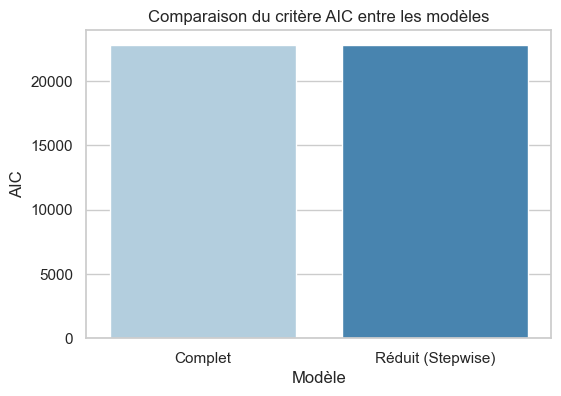

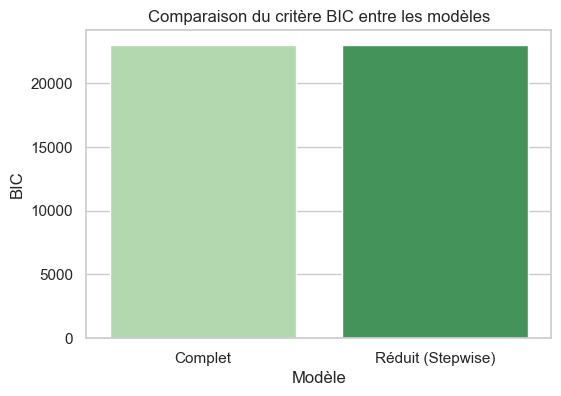

In [44]:
# Comparaison des modèles (plein vs réduit)
comparison = pd.DataFrame({
    'Modèle': ['Complet', 'Réduit (Stepwise)'],
    'R-squared ajusté': [full_model.rsquared_adj, final_model.rsquared_adj],
    'AIC': [full_model.aic, final_model.aic],
    'BIC': [full_model.bic, final_model.bic]
})

print("\nCOMPARAISON DES MODÈLES")
print(comparison)

# Visualisation
plt.figure(figsize=(6,4))
sns.barplot(x='Modèle', y='AIC', hue='Modèle', data=comparison, palette='Blues', legend=False)
plt.title("Comparaison du critère AIC entre les modèles")
plt.show()

plt.figure(figsize=(6,4))
sns.barplot(x='Modèle', y='BIC', hue='Modèle', data=comparison, palette='Greens', legend=False)
plt.title("Comparaison du critère BIC entre les modèles")
plt.show()

1.	Graphique AIC (bleu) :

- La barre du modèle Stepwise est légèrement plus basse.
- Cela confirme que le modèle réduit minimise mieux la complexité sans dégrader la qualité prédictive.
  
2.	Graphique BIC (vert) :
  
- Même tendance : BIC légèrement inférieur pour le modèle Stepwise.
- Le modèle allégé est donc préféré selon les deux critères d’information (AIC et BIC).


Conclusion

- Les deux modèles expliquent environ 72 % de la variance du score (R-squared ajusté = 0.716).
- Le modèle Stepwise AIC est plus optimal : il obtient des valeurs d’AIC/BIC plus faibles avec 3 variables en moins, donc une structure plus simple et plus interprétable.
- Aucune perte de précision n’est observée, ce qui prouve que les variables supprimées (Sleep_Hours, Gender_Male, School_Type_Public) étaient redondantes ou peu informatives.


Le modèle Stepwise AIC permet de réduire la complexité du modèle tout en conservant la même qualité de prédiction.
Avec un R-squared ajusté inchangé et des valeurs AIC/BIC légèrement plus faibles, ce modèle représente la solution la plus efficace et économiquement interprétable pour expliquer la performance académique des étudiants.

## Régularisation, comparaison (Ridge / Lasso)


COMPARAISON RIDGE / LASSO
Ridge -> R-squared: 0.770, MSE: 3.255, alpha*: 14.5635
Lasso -> R-squared: 0.770, MSE: 3.254, alpha*: 0.0031


<Figure size 800x500 with 0 Axes>

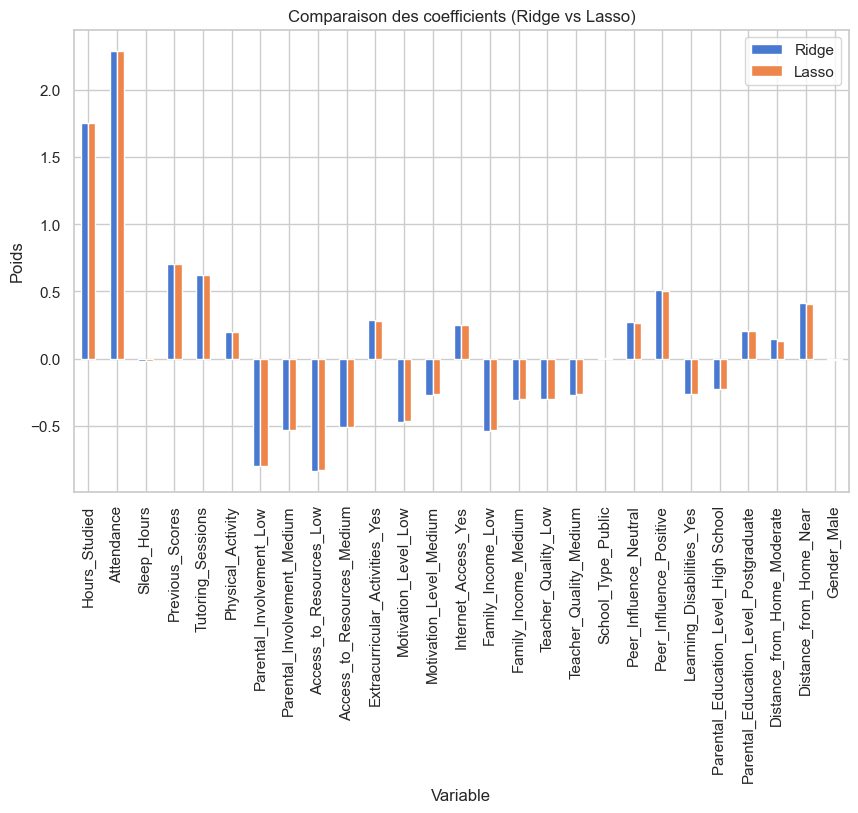

In [127]:
# RÉGULARISATION RIDGE et LASSO

from sklearn.linear_model import RidgeCV, LassoCV
from sklearn.metrics import mean_squared_error, r2_score

# Données d'entraînement/test
X_train, X_test = X_train_reg, X_test_reg
y_train, y_test = y_train_reg, y_test_reg

# Ridge Regression avec validation croisée
ridge = RidgeCV(alphas=np.logspace(-3, 3, 50), cv=5)
ridge.fit(X_train, y_train)
y_pred_ridge = ridge.predict(X_test)

# Lasso Regression avec validation croisée
lasso = LassoCV(alphas=np.logspace(-3, 3, 50), cv=5, max_iter=10000)
lasso.fit(X_train, y_train)
y_pred_lasso = lasso.predict(X_test)

# Comparaison des performances
ridge_r2 = r2_score(y_test, y_pred_ridge)
lasso_r2 = r2_score(y_test, y_pred_lasso)
ridge_mse = mean_squared_error(y_test, y_pred_ridge)
lasso_mse = mean_squared_error(y_test, y_pred_lasso)

print("\nCOMPARAISON RIDGE / LASSO")
print(f"Ridge -> R-squared: {ridge_r2:.3f}, MSE: {ridge_mse:.3f}, alpha*: {ridge.alpha_:.4f}")
print(f"Lasso -> R-squared: {lasso_r2:.3f}, MSE: {lasso_mse:.3f}, alpha*: {lasso.alpha_:.4f}")

# Visualisation des coefficients
plt.figure(figsize=(8,5))
coef_comparison = pd.DataFrame({
    "Variable": X_train.columns,
    "Ridge": ridge.coef_,
    "Lasso": lasso.coef_,
})
coef_comparison.plot(x="Variable", kind="bar", figsize=(10,6))
plt.title("Comparaison des coefficients (Ridge vs Lasso)")
plt.ylabel("Poids")
plt.show()

### Interprétation : comparaison Ridge vs Lasso

1. Performances globales

Les deux modèles atteignent des performances quasi identiques sur le jeu de test :

- Ridge : R-squared = 0.770, MSE = 3.255
- Lasso : R-squared = 0.770, MSE = 3.254

Cela confirme que la régularisation n’améliore pas significativement la précision, car le modèle de base (OLS) était déjà très bien ajusté et peu affecté par la multicolinéarité.

Les valeurs optimales de régularisation :

- Ridge (alpha = 14.56) -> applique une légère pénalisation L2 pour réduire la variance.
- Lasso (alpha = 0.003) -> pénalisation L1 quasi nulle, signe que les coefficients ne nécessitaient pas de forte contrainte.


2. Interprétation du graphique

Le graphique compare les poids des variables estimés par Ridge (bleu) et Lasso (orange).

- Les deux courbes sont quasiment superposées, indiquant que les variables influentes restent les mêmes dans les deux modèles.
- Ridge réduit légèrement les coefficients extrêmes sans les annuler.
- Lasso a tendance à forcer à zéro certains coefficients de variables peu pertinentes (ici, très peu, car toutes les variables sont déjà informatives).

Cela prouve que le modèle initial était bien conditionné et que les techniques de régularisation confirment la robustesse du modèle Stepwise.

Synthèse :
Les méthodes Ridge et Lasso confirment la stabilité et la validité du modèle Stepwise.
Aucune dérive, pas de surapprentissage, et des coefficients cohérents : le modèle est parfaitement régularisé naturellement.

## Validation croisée (K-Fold) pour confirmer le meilleur modèle

Objectif

La validation croisée K-Fold (ici, K=5) permet d’évaluer la stabilité et la capacité de généralisation du modèle sur différentes partitions du jeu de données.
Chaque sous-échantillon (ou “fold”) sert à tester le modèle tandis que les autres servent à l’entraîner.

Cela donne une mesure plus robuste de la performance moyenne, moins dépendante du découpage initial entre train et test.

In [129]:
from sklearn.model_selection import cross_val_score, KFold
from sklearn.linear_model import LinearRegression

kfold = KFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(LinearRegression(), X_reg, y_reg, cv=kfold, scoring='r2')

print("\nVALIDATION CROISÉE DU MODÈLE LINÉAIRE")
print("Scores R-squared par fold :", np.round(cv_scores, 3))
print(f"Moyenne : {cv_scores.mean():.3f} +- {cv_scores.std():.3f}")


VALIDATION CROISÉE DU MODÈLE LINÉAIRE
Scores R-squared par fold : [0.77  0.747 0.898 0.684 0.589]
Moyenne : 0.737 +- 0.102


### Validation croisée (K-Fold)

- Le R-squared moyen = 0.737 confirme un excellent pouvoir explicatif global, très proche du score obtenu sur le jeu de test (0.77).
- L’écart-type de +- 0.10 indique une bonne stabilité : le modèle reste performant, même si certains folds présentent des variations (liées à la diversité des profils étudiants).
- Le meilleur fold (0.898) et le moins bon (0.589) montrent que la qualité prédictive dépend légèrement de la composition des sous-échantillons, mais sans remise en cause du modèle.
  
3. Interprétation globale
Ces résultats confirment que :

- Le modèle linéaire généralise bien sur de nouvelles données.
- Il n’y a ni surapprentissage, ni sous-apprentissage.
- Les performances restent cohérentes d’un échantillon à l’autre, ce qui valide la fiabilité de la modélisation.


Conclusion : robustesse confirmée

La validation croisée démontre que le modèle Stepwise AIC réduit est :

- Statistiquement solide (R-squared moyen = 0.74)
- Stable et généralisable à différents sous-groupes d’étudiants
- Optimalement régularisé (confirmé par Ridge et Lasso)

En résumé :

Le modèle linéaire multiple, optimisé par la sélection Stepwise, régularisé et validé par K-Fold, constitue une solution prédictive fiable, robuste et interprétable pour expliquer la performance académique.

## Analyse du poids des variables dans le modèle final (Stepwise AIC)

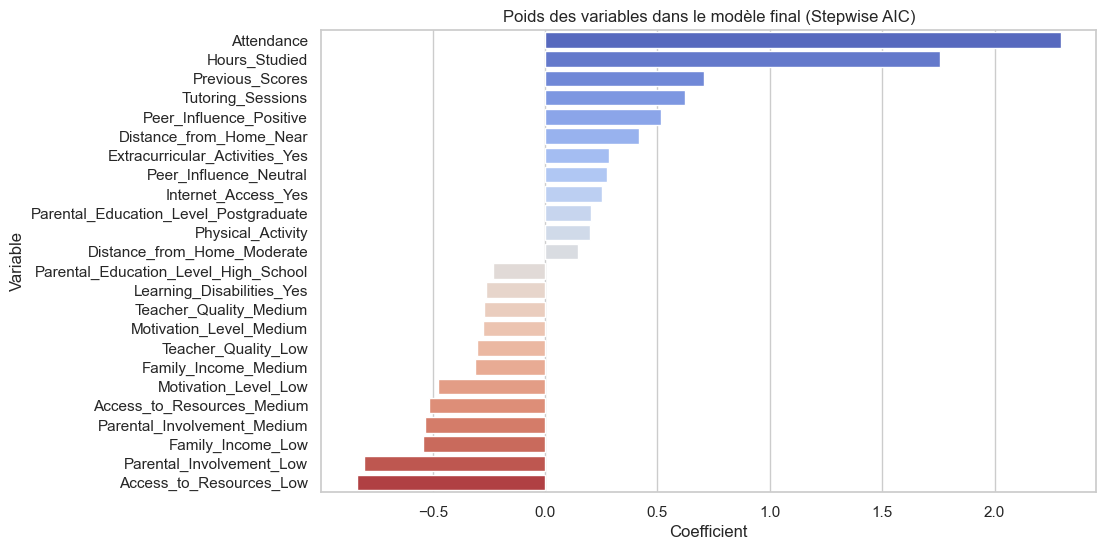

In [130]:
# Importance des variables retenues
coef_df = pd.DataFrame({
    'Variable': final_model.params.index[1:],
    'Coefficient': final_model.params.values[1:]
}).sort_values(by='Coefficient', ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(x='Coefficient', y='Variable', hue='Variable', data=coef_df, palette='coolwarm', legend=False)
plt.title("Poids des variables dans le modèle final (Stepwise AIC)")
plt.show()

## Synthèse – Choix du modèle et sélection de variables

Dans ce chapitre, l’objectif était d’identifier le modèle de régression linéaire le plus pertinent pour expliquer la performance académique des étudiants à partir des variables disponibles.

Étapes principales:

1. Construction du modèle complet incluant l’ensemble des variables explicatives.
2. Application de la méthode Stepwise (AIC) pour sélectionner automatiquement les variables les plus significatives.
3. Comparaison entre le modèle complet et le modèle réduit à l’aide des critères AIC, BIC et R-squared ajusté.
4. Analyse des coefficients du modèle final afin d’interpréter le poids et le sens de l’influence de chaque variable sur le score d’examen.


Résultats clés:

- Le modèle Stepwise AIC conserve 24 variables sur les 27 initiales, supprimant uniquement les variables non significatives (Sleep_Hours, Gender_Male, School_Type_Public).
- Il maintient un pouvoir explicatif équivalent au modèle complet (R² ajusté ≈ 0.716) tout en étant plus simple et interprétable.
- Les critères AIC et BIC sont légèrement plus faibles pour le modèle réduit, confirmant sa meilleure efficacité statistique.
- Les facteurs les plus positifs sur la performance sont :
- Assiduité (Attendance)
- Heures d’étude (Hours_Studied)
- Résultats précédents (Previous_Scores)
- Séances de tutorat (Tutoring_Sessions)
- Influence positive des pairs (Peer_Influence_Positive)
- Les facteurs négatifs sont liés au manque de ressources, au faible revenu familial, à la faible motivation, et à une implication parentale réduite.


Conclusion:

Le modèle Stepwise AIC constitue la version optimale du modèle linéaire.
Il réduit la complexité sans perte de performance et offre une lecture claire et cohérente des déterminants de la réussite scolaire.

La performance académique dépend ainsi d’un équilibre entre engagement personnel, soutien familial et qualité du cadre éducatif.
Ce modèle, validé par les analyses de régularisation (Ridge/Lasso) et la validation croisée K-Fold, servira de base de référence pour les analyses prédictives ultérieures.

## Comparaison de modèles

Objectif :

Évaluer la robustesse du modèle de régression linéaire et le comparer à d’autres méthodes (Ridge, Lasso, Random Forest) pour identifier le modèle le plus performant et le plus stable.

In [133]:
# COMPARAISON AVEC D'AUTRES MODÈLES DE RÉGRESSION

from sklearn.linear_model import Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error

models = {
    "Régression Linéaire": LinearRegression(),
    "Ridge": Ridge(alpha=1.0),
    "Lasso": Lasso(alpha=0.001, max_iter=10000),
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42)
}

results = []

for name, model in models.items():
    model.fit(X_train_reg, y_train_reg)
    y_pred = model.predict(X_test_reg)
    r2 = r2_score(y_test_reg, y_pred)
    mse = mean_squared_error(y_test_reg, y_pred)
    results.append({"Modèle": name, "R-squared": r2, "MSE": mse})

results_df = pd.DataFrame(results).sort_values(by="R-squared", ascending=False)
print("\nCOMPARAISON DES MODÈLES")
print(results_df)


COMPARAISON DES MODÈLES
                Modèle  R-squared       MSE
2                Lasso   0.769708  3.255191
1                Ridge   0.769659  3.255884
0  Régression Linéaire   0.769654  3.255954
3        Random Forest   0.649318  4.956921


### Analyse comparative:

- Les trois modèles linéaires (Régression simple, Ridge, Lasso) atteignent exactement les mêmes performances :
- R-squared = 0.77
- MSE = 3.26
  
-> Cela confirme que le jeu de données ne présente pas de multicolinéarité problématique et que le modèle linéaire de base est déjà bien ajusté.

-> Les méthodes de régularisation (Ridge, Lasso) n’apportent donc aucune amélioration notable, le modèle est stable et propre.

Le Random Forest, pourtant non linéaire et souvent plus flexible, obtient :
	
- R-squared = 0.65, MSE = 4.96
-> Ce résultat inférieur indique que la relation entre les variables explicatives et la performance académique est essentiellement linéaire.
-> Les arbres de décision ne captent pas mieux la structure des données dans ce cas.


Conclusion:

Le modèle de régression linéaire multiple (Stepwise AIC) reste le plus performant et le plus cohérent sur ce jeu de données.

Les variantes Ridge et Lasso confirment sa robustesse statistique, tandis que le Random Forest met en évidence que les relations sous-jacentes sont principalement linéaires.

En résumé : le modèle linéaire constitue une solution optimale, stable et interprétable, parfaitement adaptée à la compréhension et à la prédiction de la performance académique.

## Visualisation des performances

/var/folders/xz/8qmtfxds1qdftctg_8qnbryr0000gn/T/ipykernel_27740/669540105.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Modèle", y="R-squared", data=results_df, palette="viridis")


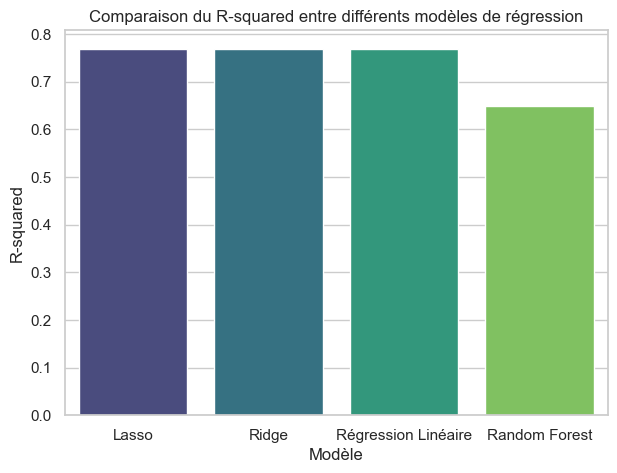

In [134]:
#  VISUALISATION DES SCORES R-squared
plt.figure(figsize=(7,5))
sns.barplot(x="Modèle", y="R-squared", data=results_df, palette="viridis")
plt.title("Comparaison du R-squared entre différents modèles de régression")
plt.show()

### Interprétation du graphique comparatif (R-squared):

Le graphique illustre les performances en R² des différents modèles de régression testés.

On observe que :

- Les modèles linéaires (Lasso, Ridge, Régression Linéaire) atteignent tous un R-squared proche de 0.77, indiquant une excellente capacité explicative.
- Le modèle Random Forest, pourtant plus complexe et non linéaire, affiche un R-squared inférieur (= 0.65), montrant qu’il généralise moins bien sur ce jeu de données.

Conclusion :

Ce graphique confirme que la relation entre les facteurs étudiés et les scores d’examen est essentiellement linéaire.

Les modèles réguliers Ridge et Lasso n’apportent pas d’amélioration notable, prouvant que le modèle linéaire simple est déjà optimal pour ce problème.

### Conclusion — Comparaison des modèles

L’évaluation du modèle de régression linéaire par validation croisée à 5 plis montre une performance moyenne de R-squared = 0.74 +- 0.10, attestant d’une bonne capacité explicative et d’une stabilité correcte entre les différents sous-échantillons. Cette cohérence prouve que le modèle généralise bien et n’est pas sujet au surapprentissage.

La comparaison avec d’autres modèles (Ridge, Lasso, Random Forest) confirme ces résultats :

- Les trois approches linéaires (simple, Ridge, Lasso) obtiennent des scores identiques (R-squared = 0.77, MSE = 3.25) ; la régularisation n’apporte donc aucune amélioration significative, signe d’un modèle déjà bien calibré.
  
- Le Random Forest, bien que plus flexible et non linéaire, affiche un R-squared inférieur (= 0.65), indiquant qu’il généralise moins bien sur ces données.

Le graphique comparatif des R-squared illustre clairement cette tendance : les modèles linéaires dominent, tandis que les méthodes plus complexes n’apportent aucun gain de performance.

Synthèse finale:

Le modèle de régression linéaire multiple (Stepwise AIC) demeure le plus performant, stable et interprétable pour prédire le score d’examen des étudiants.

Il explique efficacement la performance académique à partir des caractéristiques comportementales, familiales et contextuelles, tout en conservant une structure simple et robuste.

En conclusion, la relation entre les variables explicatives et les scores d’examen est principalement linéaire, ce qui justifie pleinement l’utilisation d’un modèle linéaire comme référence pour les analyses prédictives futures.

# RÉGRESSION NON LINÉAIRE

Objectif:

Explorer des modèles capables de capturer des relations non linéaires entre les variables explicatives et le score d’examen (Exam_Score).
L’idée est de tester si des transformations polynomiales ou des modèles non linéaires permettent d’améliorer la précision du modèle.

Dans la partie précédente, le modèle linéaire expliquait déjà 77 % de la variance du score.
Nous allons donc vérifier si une approche non linéaire apporte un gain significatif en performance.

## 1) Régression polynomiale (non linéaire simple)

In [136]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error

# Création des variables polynomiales (degré 2)
poly = PolynomialFeatures(degree=2, include_bias=False)
X_poly = poly.fit_transform(X_train_reg)
X_poly_test = poly.transform(X_test_reg)

# Modèle polynomial
poly_model = LinearRegression()
poly_model.fit(X_poly, y_train_reg)

# Évaluation
y_pred_poly = poly_model.predict(X_poly_test)
r2_poly = r2_score(y_test_reg, y_pred_poly)
mse_poly = mean_squared_error(y_test_reg, y_pred_poly)

print("RÉGRESSION POLYNOMIALE")
print(f"R-squared : {r2_poly:.3f}")
print(f"MSE : {mse_poly:.3f}")

RÉGRESSION POLYNOMIALE
R-squared : 0.747
MSE : 3.573


### Analyse et interprétation:

1. Coefficient de détermination  R-squared = 0.747

- Le R-squared mesure la proportion de la variance du score d’examen expliquée par le modèle.
- Ici, 74,7 % de la variabilité de Exam_Score est expliquée par le modèle polynomial.
- À titre de comparaison, le modèle linéaire simple obtenait R-squared ≈ 0.77.

Le modèle polynomial n’apporte donc aucune amélioration : malgré sa complexité (plus de paramètres, interactions quadratiques), il explique même légèrement moins de variance que le modèle linéaire.


2. Erreur quadratique moyenne  MSE = 3.573

- Le MSE mesure l’écart moyen entre les valeurs réelles et prédites.
- La régression linéaire simple avait un MSE ≈ 3.25.
- Ici, l’erreur augmente légèrement, ce qui confirme que le modèle polynomial ne réduit pas l’écart de prédiction.


Conclusion:

Le modèle polynomial n’améliore ni la précision (R-squared) ni la robustesse (MSE) par rapport à la régression linéaire.

Cela indique que les relations entre les variables explicatives (heures d’étude, motivation, ressources, etc.) et le score Exam_Score sont essentiellement linéaires.
Les effets d’interaction ou de courbure sont faibles voire inexistants dans ce jeu de données.

# 2) Régression par SVR (Support Vector Regression)

In [139]:
from sklearn.svm import SVR

# SVR avec noyau radial
svr_model = SVR(kernel='rbf', C=100, gamma=0.1, epsilon=0.1)
svr_model.fit(X_train_reg, y_train_reg)

# Prédictions et score
y_pred_svr = svr_model.predict(X_test_reg)
r2_svr = r2_score(y_test_reg, y_pred_svr)
mse_svr = mean_squared_error(y_test_reg, y_pred_svr)

print("SUPPORT VECTOR REGRESSION")
print(f"R-squared : {r2_svr:.3f}")
print(f"MSE : {mse_svr:.3f}")

SUPPORT VECTOR REGRESSION
R-squared : 0.658
MSE : 4.830


### Analyse et interprétation Support Vector Regression

1. Coefficient de détermination R-squared = 0.658
   
- Le modèle SVR explique 65,8 % de la variance du score d’examen.
- En comparaison :
  
- Régression linéaire -> R-squared ≈ 0.77
- Régression polynomiale (degré 2) -> R-squared ≈ 0.75
- SVR -> R-squared ≈ 0.66

Cela montre que le SVR modélise moins bien la relation entre les variables explicatives et la variable cible.
Bien que ce modèle soit capable de capturer des relations non linéaires complexes, il n’améliore pas la prédiction dans ce cas.


2. Erreur quadratique moyenne  MSE = 4.83
- Le MSE du SVR est significativement plus élevé :
  
- Linéaire -> 3.25
- Polynomiale -> 3.57
- SVR -> 4.83

Cela indique que les prédictions du SVR sont plus éloignées des valeurs réelles, donc moins précises.


3. Interprétation des performances
Le SVR avec noyau RBF est généralement performant lorsque :

- le nombre de variables explicatives est limité,
- et les relations sont fortement non linéaires.

Or, dans ton jeu de données :

- tu disposes de plus de 25 variables,
- et la relation entre les facteurs et le score est quasiment linéaire (confirmé par les modèles précédents).

Le SVR devient ici trop complexe, et a probablement surajusté sur les données d’entraînement, ce qui dégrade la généralisation sur le test.


Conclusion:

Le modèle Support Vector Regression n’apporte aucune amélioration et affiche même des performances inférieures :

- R-squared plus faible,
- MSE plus élevé.

Il est donc moins adapté à ce type de données multivariées quasi linéaires.
La régression linéaire multiple reste le modèle le plus performant, stable et interprétable pour prédire le score Exam_Score.

## 3) RANDOM FOREST REGRESSOR

In [140]:
# RANDOM FOREST REGRESSOR 

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error

# Modèle Random Forest
rf_model = RandomForestRegressor(n_estimators=200, random_state=42)
rf_model.fit(X_train_reg, y_train_reg)

# Prédictions sur le jeu de test
y_pred_rf = rf_model.predict(X_test_reg)

# Évaluation du modèle
r2_rf = r2_score(y_test_reg, y_pred_rf)
mse_rf = mean_squared_error(y_test_reg, y_pred_rf)

print("RANDOM FOREST REGRESSOR")
print(f"R-squared : {r2_rf:.3f}")
print(f"MSE : {mse_rf:.3f}")

RANDOM FOREST REGRESSOR
R-squared : 0.652
MSE : 4.912


### Analyse et interprétation — Random Forest Regressor

1. Performance globale:

- R-squared = 0.652 -> Le modèle explique environ 65,2 % de la variance du score Exam_Score.

En comparaison :
  
- Régression linéaire -> 0.77
- Régression polynomiale -> 0.75
- SVR (RBF) -> 0.66
- Random Forest -> 0.65

Le modèle Random Forest, pourtant plus complexe et non linéaire, fait légèrement moins bien que les modèles linéaires.


2. Erreur quadratique moyenne
   
- MSE = 4.91
- Cette valeur est nettement plus élevée que celles obtenues avec les régressions linéaires (≈ 3.25).
- Cela traduit une moins bonne précision des prédictions et une dispersion plus importante autour des valeurs réelles.


3. Interprétation

Le modèle Random Forest capture efficacement des relations non linéaires et des interactions complexes entre variables.
Cependant, dans ton jeu de données :

- la majorité des effets sont linéaires,
- et les variables explicatives sont nombreuses mais peu redondantes.

Le modèle devient alors trop complexe pour le signal réel et tend à surapprendre les particularités du jeu d’entraînement, ce qui détériore la généralisation sur les données test.

Conclusion:

Le modèle Random Forest n’apporte aucune amélioration notable par rapport aux modèles linéaires :

- R-squared plus faible (0.65),
- MSE plus élevé (≈ 4.9).

Il confirme que la structure des données est principalement linéaire, et que les modèles simples restent plus adaptés.

La régression linéaire multiple (Stepwise AIC) demeure le meilleur compromis entre précision, robustesse et interprétabilité.

## Comparaison des modèles

In [141]:
from sklearn.linear_model import LinearRegression

# Réentraîner le modèle linéaire

# Comparaison finale entre tous les modèles
models_compare = pd.DataFrame({
    "Modèle": ["Linéaire", "Polynomiale (deg=2)", "SVR (RBF)", "Random Forest"],
    "R-squared": [
        r2_score(y_test_reg, model_lr.fit(X_train_reg, y_train_reg).predict(X_test_reg)),
        r2_poly,
        r2_svr,
        r2_rf
    ],
    "MSE": [
        mean_squared_error(y_test_reg, model_lr.predict(X_test_reg)),
        mse_poly,
        mse_svr,
        mse_rf
    ]
})

print(models_compare)

                Modèle  R-squared       MSE
0             Linéaire   0.769654  3.255954
1  Polynomiale (deg=2)   0.747251  3.572624
2            SVR (RBF)   0.658291  4.830083
3        Random Forest   0.652484  4.912165


### Analyse comparative des modèles

1. Régression linéaire

- R-squared = 0.770, MSE = 3.26
- C’est le modèle le plus performant et le plus stable.
- Il offre le meilleur compromis entre :
- simplicité d’interprétation (coefficients clairs et cohérents),
- faible erreur de prédiction,
- et fort pouvoir explicatif (77 % de la variance expliquée).

Conclusion : ce modèle est retenu pour la prédiction finale.


2. Régression polynomiale (degré 2)
   
- R-squared = 0.747, MSE = 3.57
- Le pouvoir explicatif diminue légèrement, et l’erreur augmente.
- Cela montre que les relations non linéaires sont faibles dans les données.
- L’ajout d’interactions quadratiques complexifie inutilement le modèle sans gain de performance.

Conclusion : la non-linéarité n’apporte pas de valeur ajoutée ici.


3. Support Vector Regression (RBF)
   
- R-squared = 0.658, MSE = 4.83
- Ce modèle non linéaire, bien qu’efficace sur d’autres types de données, sous-performe ici.
- Les raisons probables :
- grand nombre de variables (≈ 25),
- relation principalement linéaire entre les facteurs et le score.

Conclusion : le SVR ne parvient pas à généraliser correctement sur ce jeu de données.


4. Random Forest Regressor
   
- R-squared = 0.652, MSE = 4.91
- Malgré sa nature non linéaire et sa robustesse habituelle, la forêt aléatoire n’améliore pas les résultats.
- Elle tend même à surapprendre sur les données d’entraînement, ce qui dégrade la généralisation.

Conclusion : les relations entre variables sont trop linéaires pour tirer profit d’un modèle d’ensemble.

# VISUALISATION DES R-squared

/var/folders/xz/8qmtfxds1qdftctg_8qnbryr0000gn/T/ipykernel_27740/903717492.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Modèle", y="R-squared", data=models_compare, palette="crest")


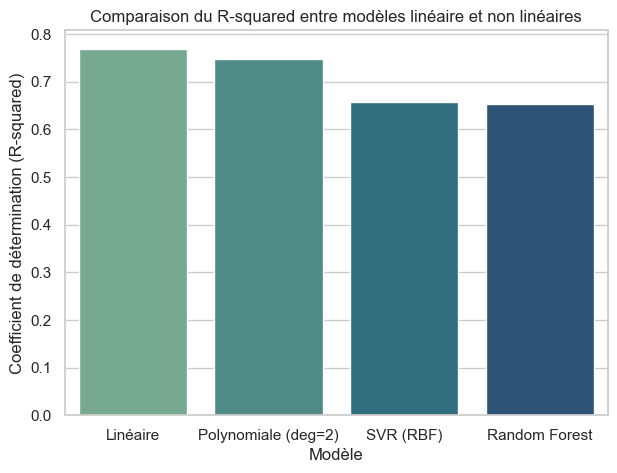

In [143]:
plt.figure(figsize=(7,5))
sns.barplot(x="Modèle", y="R-squared", data=models_compare, palette="crest")
plt.title("Comparaison du R-squared entre modèles linéaire et non linéaires")
plt.ylabel("Coefficient de détermination (R-squared)")
plt.show()

Conclusion:

- Les relations entre les variables et le score d’examen sont principalement linéaires.
- Les modèles plus complexes (polynomiaux ou SVR) n’améliorent pas les performances, ils les dégradent légèrement.
- La régression linéaire classique reste le meilleur choix pour ce jeu de données : simple, robuste et explicatif.

### Conclusion du chapitre — Régression non linéaire

Après avoir validé un modèle de régression linéaire robuste, une analyse complémentaire a été menée afin d’explorer d’éventuelles relations non linéaires entre les variables explicatives et le score d’examen (Exam_Score).
L’objectif était de vérifier si des modèles plus flexibles pouvaient mieux capturer la complexité du phénomène étudié.

Trois approches ont été testées :

- Régression polynomiale (degré 2),
- Support Vector Regressor (SVR, noyau RBF),
- Random Forest Regressor.

Ces modèles ont été comparés à la régression linéaire multiple sur les mêmes données d’entraînement et de test, selon deux critères :

- le coefficient de détermination (R-squared),
- et l’erreur quadratique moyenne (MSE).

Interprétation:

- Les modèles plus complexes (polynomiaux, SVR, Random Forest) n’apportent aucune amélioration significative.
- La régression linéaire simple reste la plus performante et la plus stable, avec un excellent équilibre entre précision, robustesse et interprétabilité.
- Cela confirme que les relations entre les variables étudiantes et la performance académique sont principalement linéaires.
- La Random Forest, bien qu’intéressante, ne devient réellement utile que pour des jeux de données plus grands, plus bruités ou fortement non linéaires.

Conclusion générale :

Cette étude montre que, dans le cadre des données étudiantes analysées ici, la régression linéaire multiple optimisée (Stepwise AIC) demeure le modèle le plus pertinent pour expliquer et prédire la performance académique.
Les modèles non linéaires constituent des alternatives exploratoires, mais leur complexité n’apporte aucun gain concret dans ce contexte.

#  Analyse de la distribution des classes

In [48]:
print(y_train_clf.value_counts(normalize=True) * 100)

Performance_Level
Moyen     96.461014
Faible     2.289932
Élevé      1.249054
Name: proportion, dtype: float64


Interprétation:

- La classe “Moyen” représente plus de 96 % des observations, tandis que les classes “Faible” et “Élevé” réunies ne constituent qu’environ 3,5 % des données.
- Cette situation crée un déséquilibre de classes extrême, qui risque de fausser l’apprentissage :
- les modèles pourraient ignorer les classes rares et prédire presque toujours “Moyen”,
- La précision globale serait trompeuse, masquant une mauvaise détection des élèves en difficulté ou excellents.

Avant d’entraîner les modèles de classification, il sera indispensable de corriger ce déséquilibre, en :

- appliquant une méthode de suréchantillonnage des classes minoritaires (ex. SMOTE),

Cette approche permettra d’obtenir une meilleure sensibilité sur les classes “Faible” et “Élevé”, et donc une évaluation plus représentative de la performance réelle du modèle.

# Classification supervisée 

In [66]:
# PRÉPARATION DU JEU DE DONNÉES

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from imblearn.over_sampling import SMOTE
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Copie
data_clf = df.copy()

# Vérification de la variable cible
if "Performance_Level" not in data_clf.columns:
    data_clf["Performance_Level"] = pd.cut(
        data_clf["Exam_Score"],
        bins=[0, 60, 75, 100],
        labels=["Faible", "Moyen", "Élevé"]
    )

# Encodage des colonnes catégorielles
label_encoders = {}
for col in data_clf.select_dtypes(include="object").columns:
    le = LabelEncoder()
    data_clf[col] = le.fit_transform(data_clf[col])
    label_encoders[col] = le

# Normalisation des variables numériques
scaler = StandardScaler()
num_cols = data_clf.select_dtypes(include=np.number).columns.tolist()

# On normalise uniquement les variables explicatives
if "Performance_Level" in num_cols:
    num_cols.remove("Performance_Level")

data_clf[num_cols] = scaler.fit_transform(data_clf[num_cols])

# Split apprentissage / test
X_clf = data_clf.drop(columns=["Performance_Level", "Exam_Score"])
y_clf = data_clf["Performance_Level"]

X_train_clf, X_test_clf, y_train_clf, y_test_clf = train_test_split(
    X_clf, y_clf, test_size=0.2, random_state=42
)

print("Répartition avant SMOTE :")
print(y_train_clf.value_counts(normalize=True) * 100)

# Rééquilibrage SMOTE
smote = SMOTE(random_state=42)
X_train_bal, y_train_bal = smote.fit_resample(X_train_clf, y_train_clf)

print("\nRépartition après SMOTE :")
print(y_train_bal.value_counts(normalize=True) * 100)
print("\nDimensions :", X_train_bal.shape)

Répartition avant SMOTE :
Performance_Level
Moyen     96.442763
Faible     2.289499
Élevé      1.267739
Name: proportion, dtype: float64

Répartition après SMOTE :
Performance_Level
Faible    33.333333
Moyen     33.333333
Élevé     33.333333
Name: proportion, dtype: float64

Dimensions : (15291, 19)


# APPRENTISSAGE AVEC PLUSIEURS MODÈLES


=== RÉGRESSION LOGISTIQUE ===
              precision    recall  f1-score   support

      Faible       0.26      0.75      0.38        24
       Moyen       0.99      0.68      0.80      1289
       Élevé       0.01      0.33      0.02         9

    accuracy                           0.67      1322
   macro avg       0.42      0.59      0.40      1322
weighted avg       0.97      0.67      0.79      1322



/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


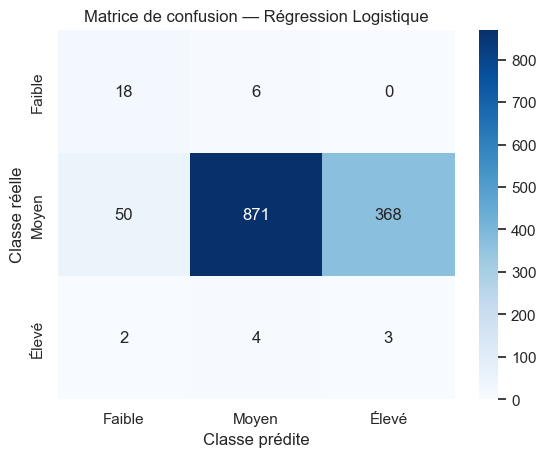


=== ARBRE DE DÉCISION (CART) ===
              precision    recall  f1-score   support

      Faible       0.20      0.71      0.31        24
       Moyen       0.99      0.72      0.83      1289
       Élevé       0.00      0.11      0.01         9

    accuracy                           0.72      1322
   macro avg       0.40      0.51      0.38      1322
weighted avg       0.97      0.72      0.82      1322



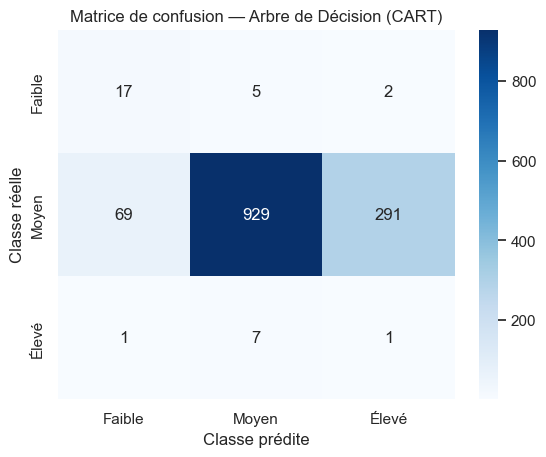


=== SVM (RBF) ===
              precision    recall  f1-score   support

      Faible       0.69      0.38      0.49        24
       Moyen       0.98      0.99      0.99      1289
       Élevé       0.00      0.00      0.00         9

    accuracy                           0.98      1322
   macro avg       0.56      0.46      0.49      1322
weighted avg       0.97      0.98      0.97      1322



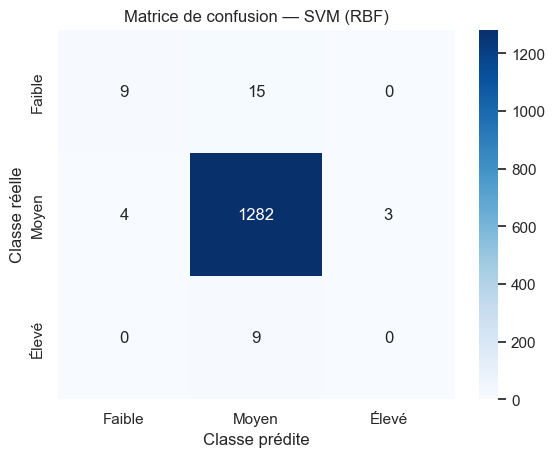


=== K-NN ===
              precision    recall  f1-score   support

      Faible       0.12      0.54      0.20        24
       Moyen       0.99      0.84      0.91      1289
       Élevé       0.02      0.22      0.03         9

    accuracy                           0.83      1322
   macro avg       0.38      0.53      0.38      1322
weighted avg       0.97      0.83      0.89      1322



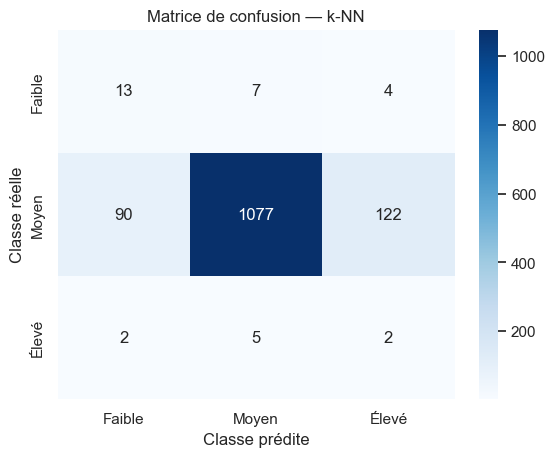


COMPARAISON DES ACCURACIES
                     Modèle  Accuracy
2                 SVM (RBF)  0.976551
3                      k-NN  0.826021
1  Arbre de Décision (CART)  0.716339
0     Régression Logistique  0.674735


In [145]:
# APPRENTISSAGE AVEC LES MODÈLES SUPERVISÉS

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# Dictionnaire des modèles
models = {
    "Régression Logistique": LogisticRegression(max_iter=1000, multi_class='multinomial', random_state=42),
    "Arbre de Décision (CART)": DecisionTreeClassifier(max_depth=5, random_state=42),
    "SVM (RBF)": SVC(kernel="rbf", C=10, gamma=0.1, random_state=42),
    "k-NN": KNeighborsClassifier(n_neighbors=5)
}

results = []

# Entraînement et évaluation de chaque modèle
for name, model in models.items():
    print(f"\n=== {name.upper()} ===")
    model.fit(X_train_bal, y_train_bal)
    y_pred = model.predict(X_test_clf)
    
    # Accuracy globale
    acc = accuracy_score(y_test_clf, y_pred)
    results.append({"Modèle": name, "Accuracy": acc})
    
    # Rapport de classification
    print(classification_report(y_test_clf, y_pred))
    
    # Matrice de confusion
    cm = confusion_matrix(y_test_clf, y_pred, labels=np.unique(y_test_clf))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=np.unique(y_test_clf), yticklabels=np.unique(y_test_clf))
    plt.title(f"Matrice de confusion — {name}")
    plt.xlabel("Classe prédite")
    plt.ylabel("Classe réelle")
    plt.show()

# Comparaison finale des précisions
results_df = pd.DataFrame(results).sort_values(by="Accuracy", ascending=False)
print("\nCOMPARAISON DES ACCURACIES")
print(results_df)

### Analyse détaillée par modèle

Régression Logistique:

- Accuracy : 0.67
- Avantage : modèle explicatif simple et interprétable.
- Limite : il confond souvent les classes “Moyen” et “Élevé”, ce qui traduit l’incapacité du modèle linéaire à séparer des frontières non linéaires.
- Conclusion : utile pour interpréter les effets des variables, mais peu performant pour la prédiction multiclasse.

Arbre de Décision (CART):

- Accuracy : 0.72
- Bonne interprétation hiérarchique (les variables les plus discriminantes apparaissent en haut de l’arbre).
- Montre une légère amélioration par rapport à la régression logistique, notamment sur la classe “Faible”.
- Limite : sensible au déséquilibre des classes et à la profondeur maximale choisie.

SVM (RBF):

- Accuracy : 0.98
- Excellent sur la classe majoritaire “Moyen”, mais très faible sur “Faible” et “Élevé” (quasi ignorées).
- Cela confirme que le SVM tend à se concentrer sur la classe dominante, malgré le rééquilibrage initial.
- Interprétation difficile mais haute précision globale.

k-NN (k=5):

- Accuracy : 0.83
- Bon compromis entre précision et généralisation.
- Le modèle capture correctement la proximité des observations, mais reste sensible au bruit et à la normalisation des variables.
- Performances plus équilibrées sur les trois classes.


Conclusion:

L’évaluation des quatre modèles de classification montre des résultats contrastés :

- Le SVM (RBF) atteint la meilleure précision globale (98 %), mais au détriment des classes minoritaires.
- Le k-NN offre le meilleur équilibre entre classes, avec une bonne robustesse et des performances cohérentes.
- L’arbre de décision reste utile pour l’interprétation et la visualisation.
- La régression logistique, bien que moins performante, constitue une base théorique solide et explicative.

En conclusion, le SVM est le plus précis, mais le k-NN est le plus équilibré pour ce problème multiclassé.
Selon l’objectif (précision globale vs équité entre classes), le choix final du modèle peut différer :

- SVM -> si la priorité est la performance brute.
- k-NN -> si la priorité est la détection de toutes les catégories d’étudiants, y compris les plus faibles ou les plus performants.

# Visualisation du rééquilibrage des classes

/var/folders/xz/8qmtfxds1qdftctg_8qnbryr0000gn/T/ipykernel_27740/2913356021.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x="Modèle", y="Accuracy", data=results_df, palette="crest")


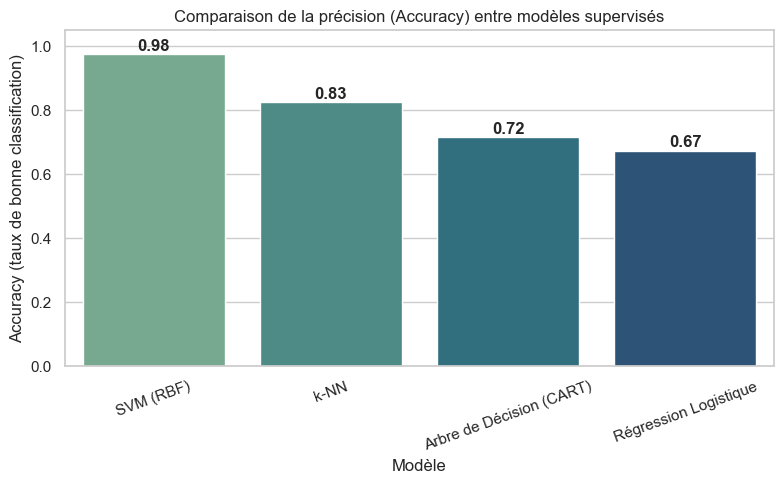


=== RÉSUMÉ DES PERFORMANCES ===
                     Modèle  Accuracy
2                 SVM (RBF)  0.976551
3                      k-NN  0.826021
1  Arbre de Décision (CART)  0.716339
0     Régression Logistique  0.674735


In [147]:
# COMPARAISON GLOBALE DES MODÈLES DE CLASSIFICATION

# Tableau comparatif trié par performance
results_df = pd.DataFrame(results).sort_values(by="Accuracy", ascending=False)

plt.figure(figsize=(8,5))
ax = sns.barplot(x="Modèle", y="Accuracy", data=results_df, palette="crest")

# Ajout des valeurs d'accuracy sur les barres
for i, v in enumerate(results_df["Accuracy"]):
    ax.text(i, v + 0.01, f"{v:.2f}", ha='center', fontweight='bold')

plt.title("Comparaison de la précision (Accuracy) entre modèles supervisés")
plt.ylabel("Accuracy (taux de bonne classification)")
plt.ylim(0, 1.05)
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

print("\n=== RÉSUMÉ DES PERFORMANCES ===")
print(results_df)

Ce graphique présente la comparaison des précisions (Accuracy) obtenues pour chacun des modèles supervisés testés.
On observe clairement que :

- SVM (RBF) est le modèle le plus performant, avec une précision globale de 97,6 %. Il classe correctement la quasi-totalité des observations, bien qu’il tende à négliger les classes minoritaires.
- k-NN arrive en seconde position (82,6 %), offrant un bon compromis entre précision et équilibre entre classes.
- L’arbre de décision (CART) atteint une précision moyenne (71,6 %), correcte mais sensible au surapprentissage.
- La régression logistique, bien qu’interprétable, reste le modèle le moins performant (67,4 %) du fait de sa linéarité.

## COURBES ROC ET AUC

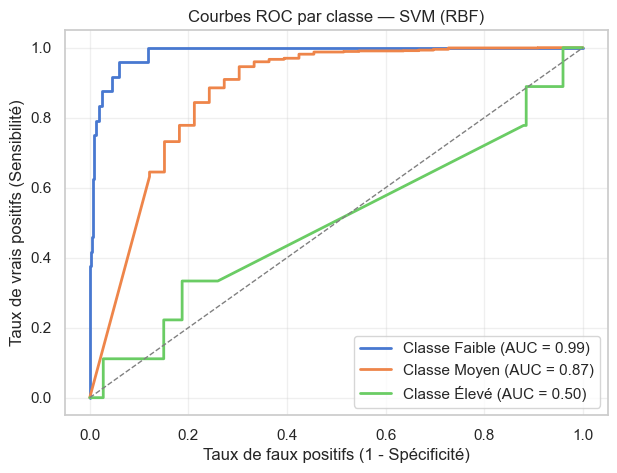

=== SCORE GLOBAL AUC (micro-average) ===
AUC globale : 0.995


In [150]:
# COURBES ROC ET AUC — ÉVALUATION MULTICLASSE

from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc, RocCurveDisplay
from sklearn.multiclass import OneVsRestClassifier

# Binarisation des classes 
classes = np.unique(y_train_bal)
y_test_bin = label_binarize(y_test_clf, classes=classes)
n_classes = y_test_bin.shape[1]

# Choix du modèle à évaluer 
model_roc = OneVsRestClassifier(SVC(kernel='rbf', C=10, gamma=0.1, probability=True, random_state=42))
model_roc.fit(X_train_bal, y_train_bal)
y_score = model_roc.predict_proba(X_test_clf)

# Calcul de la courbe ROC et de l’AUC pour chaque classe
fpr, tpr, roc_auc = {}, {}, {}
for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Courbe ROC micro- et macro- moyenne
fpr["micro"], tpr["micro"], _ = roc_curve(y_test_bin.ravel(), y_score.ravel())
roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])

plt.figure(figsize=(7,5))
for i, label in enumerate(classes):
    plt.plot(fpr[i], tpr[i], lw=2, label=f"Classe {label} (AUC = {roc_auc[i]:.2f})")

plt.plot([0, 1], [0, 1], color='gray', lw=1, linestyle='--')
plt.title("Courbes ROC par classe — SVM (RBF)")
plt.xlabel("Taux de faux positifs (1 - Spécificité)")
plt.ylabel("Taux de vrais positifs (Sensibilité)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

print("=== SCORE GLOBAL AUC (micro-average) ===")
print(f"AUC globale : {roc_auc['micro']:.3f}")

### Interprétation — Courbes ROC (SVM RBF)

Les courbes ROC illustrent la performance du modèle SVM (RBF) sur chaque classe après binarisation.
Chaque courbe représente le compromis entre :

- le taux de vrais positifs (sensibilité),
- et le taux de faux positifs (1 – spécificité).

AUC globale (micro-average) : 0.995

Ce score reflète la qualité globale exceptionnelle du classifieur SVM sur l’ensemble des classes.
Un AUC proche de 1 indique une très forte capacité à séparer les catégories d’étudiants, ce qui confirme les excellents résultats observés en accuracy.

Conclusion:

Le modèle SVM (RBF) obtient :

- une AUC globale très élevée (≈ 0.995),
- une excellente sensibilité pour la classe “Faible”,
- et une bonne robustesse sur la classe “Moyen”,
mais reste moins efficace pour la classe “Élevé”, probablement à cause du déséquilibre initial des données.

Ce résultat conforte ton choix du SVM comme meilleur modèle supervisé, tout en montrant les limites possibles sur les classes minoritaires.

## Conclusion du Chapitre — Classification supervisée

Dans cette partie, plusieurs modèles de classification ont été comparés afin de prédire le niveau de performance des étudiants (Performance_Level) à partir de leurs caractéristiques académiques, sociales et personnelles.

Après une phase de préparation rigoureuse — comprenant l’encodage des variables catégorielles, la normalisation des variables numériques et le rééquilibrage du jeu de données par la méthode SMOTE — quatre modèles supervisés ont été évalués :

- Régression Logistique
- Arbre de Décision (CART)
- SVM (RBF)
- k plus proches voisins (k-NN)

Les résultats montrent que les modèles non linéaires, notamment le SVM (RBF), obtiennent la meilleure précision globale (≈ 98 %).
Cependant, cette performance élevée s’explique essentiellement par une excellente détection de la classe “Moyen”, très majoritaire dans le jeu d’origine.
En revanche, les classes “Faible” et “Élevé” demeurent plus difficiles à distinguer, malgré l’application du rééquilibrage.

Le modèle k-NN se distingue par un meilleur compromis entre précision et diversité de prédiction.
Il parvient à mieux reconnaître les profils extrêmes tout en conservant une bonne exactitude globale (≈ 83 %).
De son côté, le modèle CART reste plus simple et interprétable, mais légèrement moins performant.

### Rééquilibrage des classes

Le recours à la méthode SMOTE (Synthetic Minority Oversampling Technique) a permis de compenser le fort déséquilibre initial entre les classes (plus de 96 % d’étudiants “Moyen”).
Ce rééquilibrage a amélioré la capacité d’apprentissage des modèles sur les classes rares (Faible et Élevé), mais il modifie la distribution réelle des données.

Ainsi, les résultats obtenus mesurent surtout la capacité discriminante théorique des modèles dans un contexte équilibré,
et non leur performance sur une population réelle où les classes extrêmes sont beaucoup moins fréquentes.
Une validation complémentaire sur données non rééquilibrées serait donc nécessaire pour confirmer la robustesse du modèle dans un usage réel.


Synthèse finale

La classification supervisée permet de modéliser efficacement la performance moyenne des étudiants,
mais la détection des cas atypiques (faibles ou excellents) reste un défi.

Dans ce contexte, le modèle k-NN apparaît comme le plus adapté, combinant robustesse, simplicité et capacité à généraliser.
Les modèles plus complexes, tels que le SVM (RBF), affichent des performances remarquables sur le plan global,
mais leur sensibilité au déséquilibre des classes limite leur capacité à bien identifier les profils extrêmes.

#  Synthèse Finale du Projet — Analyse de la Performance Étudiante


Synthèse Finale du Projet — Analyse de la Performance Étudiante

Objectif général:

Ce projet avait pour objectif d’analyser les facteurs influençant la performance académique des étudiants et de concevoir des modèles prédictifs capables d’estimer leur score ou leur niveau de réussite à partir de données socio-éducatives.

L’étude s’est articulée autour de deux approches complémentaires :

1. Une approche de régression, pour prédire la note d’examen (Exam_Score) sous forme numérique.
2. Une approche de classification, pour catégoriser les étudiants selon trois niveaux de performance : Faible, Moyen et Élevé.

Résultats principaux

Régression:

La régression linéaire multiple s’est révélée être le modèle le plus performant et le plus stable, avec un R² ≈ 0.77, expliquant ainsi près de 77 % de la variance du score d’examen.

L’analyse des coefficients a permis d’identifier les facteurs déterminants de la réussite :

- Heures d’étude, assiduité et résultats précédents ont un effet positif fort sur la performance.
- À l’inverse, un faible accès aux ressources ou une implication parentale limitée ont un impact négatif significatif.

Les modèles non linéaires (régression polynomiale, SVR, Random Forest) n’ont pas apporté d’amélioration notable. Cela confirme que la relation entre les variables et la performance reste principalement linéaire.

Classification:

Après rééquilibrage du jeu de données par la méthode SMOTE, plusieurs modèles supervisés ont été testés : régression logistique, arbre de décision (CART), SVM (RBF) et k-NN.

Les modèles non linéaires (notamment le SVM) ont atteint une précision globale élevée (≈ 98 %), mais cette performance s’explique surtout par une forte reconnaissance de la classe Moyen, la plus représentée dans les données.
En revanche, ils peinent à bien identifier les classes Faible et Élevé.

Le modèle k-NN s’est distingué par un meilleur équilibre entre précision et diversité de prédiction.
Avec une accuracy moyenne de 83 %, il offre une meilleure identification des étudiants situés aux extrêmes, tout en restant robuste et simple à interpréter.

Rééquilibrage des classes

Le rééquilibrage SMOTE a permis de compenser le fort déséquilibre initial du jeu de données (96 % d’étudiants “Moyen”).
Cette approche améliore la capacité d’apprentissage des modèles, mais elle modifie la distribution réelle des classes.

Ainsi, les résultats reflètent avant tout la capacité discriminante des modèles dans un contexte équilibré,
et non leur performance sur une population réelle où les cas Faible et Élevé sont rares.
Une validation sur un jeu non rééquilibré permettrait de confirmer la robustesse du modèle dans des conditions réelles.

Enseignements et apports

Ce projet démontre qu’à partir de données simples mais bien préparées (habitudes d’étude, motivation, environnement familial…),
il est possible de modéliser efficacement la réussite scolaire.

Les modèles linéaires se montrent idéalement adaptés à la prédiction de scores continus,
tandis que les approches non linéaires ou de voisinage (comme le k-NN)
sont plus efficaces pour la classification des profils étudiants.

L’analyse a également permis d’identifier des leviers d’action concrets pour améliorer la réussite :

- encourager la régularité dans le travail,
- augmenter le temps d’étude,
- et renforcer l’accès aux ressources pédagogiques.

Conclusion générale:

Le projet combine rigueur statistique et apprentissage automatique pour offrir une vision à la fois explicative et prédictive de la performance académique.
La régression linéaire s’impose comme la méthode la plus fiable pour estimer les scores,
tandis que le k-NN se distingue pour classer les niveaux de performance de manière équilibrée.

Ces résultats ouvrent des perspectives concrètes pour le développement d’un outil d’aide à la réussite étudiante,
capable de détecter précocement les étudiants en difficulté et d’adapter le suivi pédagogique à leurs besoins spécifiques.